<a href="https://colab.research.google.com/github/nephelim74/machinelearn/blob/main/%D0%9F%D1%80%D0%B8%D0%BC%D0%B5%D1%80_%D1%80%D0%B0%D0%B7%D0%B1%D0%BE%D1%80%D0%B0_%D0%B4%D0%B7_MOB2_11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## ЦЕЛЬ: создать модель предсказания того, уйдёт ли аббонент в отток(church)

## Информация об атрибутах приведена ниже:

- Customer ID - уникальный номер клиента
- gender - пол
- SeniorCitizen - является ли клиент пенсионером или нет (1, 0)
- Partner - имеется ли у клиента партнер (Да, Нет)
- Dependents - имеет ли клиент иждивенцев или нет (Да, Нет)
- tenure - количество месяцев, которое клиент провел в компании
- PhoneService - имеет ли клиент телефонное обслуживание или нет (Да, Нет)
- MultipleLines - имеет ли клиент несколько линий или нет (Да, Нет, Нет телефонного обслуживания)
- InternetService - поставщик услуг интернет-провайдера (DSL, оптоволокно, нет)
- OnlineSecurity - имеется ли у клиента онлайн-безопасность или нет (Да, Нет, Нет Интернет-сервис)
- OnlineBackup - прибегал ли клиент к резервному копированию в интернете (Да, Нет, Нет телефонного обслуживания)
- DeviceProtection - подключена ли у клиента защита устройства (Да, Нет, Нет телефонного обслуживания)
- TechSupport - имеется ли у клиента техническая поддержка устройства (Да, Нет, Нет телефонного обслуживания)
- StreamingTV - имеется ли у клиента онлайн трансляция телевизионных программ и видео контента через интернет (Да, Нет, Нет телефонного обслуживания)
- StreamingMovies - имеется ли у клиента сервис, который предоставляет доступ к фильмам и телевизионным шоу через интернет для просмотра на устройствах, подключенных к сети (Да, Нет, Нет телефонного обслуживания)
- Contract - срок действия контракта клиента
- PaperlessBilling - отправляет ли клиент счета и квитанции за услуги или товары электронным способом (Да, Нет, Нет телефонного обслуживания)
- PaymentMethod - способ оплаты клиента
- MonthlyCharges - ежемесячные расходы клиента
- TotalCharges - общие расходы клиента
- church - отток клиента(Да, Нет)


## Импортируем библиотеки

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

## Импортируем исследуемый датасет

In [2]:
url = "https://raw.githubusercontent.com/shabmei/Telco-Customer-Churn/main/Telco-Customer-Churn.csv"
df = pd.read_csv(url)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


## Проверим тип данных и есть ли отсутствующие данные в датасете

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Видно, что пропусков и отсутствующих данных не имеется

## Выведим статистические метрики для числовых колонок.

In [4]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


## Видно, что большинство колонок являются категориальными, поэтому для них будем создавать дамми-переменные

## Проведём тщательное исследование данных. Убедимся, что в этих данных нет отсутствующих значений

In [5]:
df.isnull().sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


## Мы получили все 0, что означает отсутствующих значений нет

## Перейдём к визуализации данных

## Построим график CountPlot для проверки сбалансированности значений колонки с классами(Church)

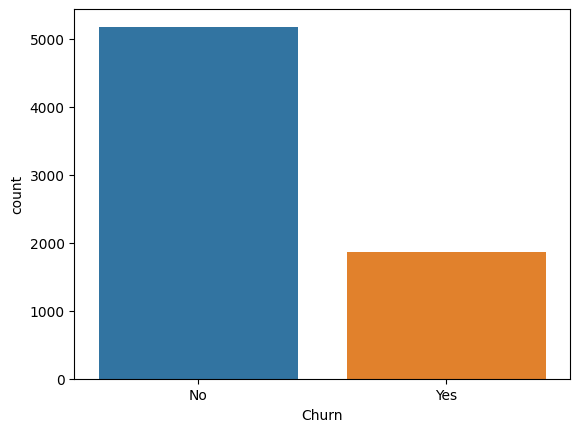

In [6]:
sns.countplot(x='Churn', data=df, hue='Churn');

In [7]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869


## Заметно сразу, что классы несбалансированны. Но данная разница между классами не является громадной.

## Теперь исследуем распределение колонки TotalCharges по различным категориям Churn с помощью графика Box Plot или Violin Plot

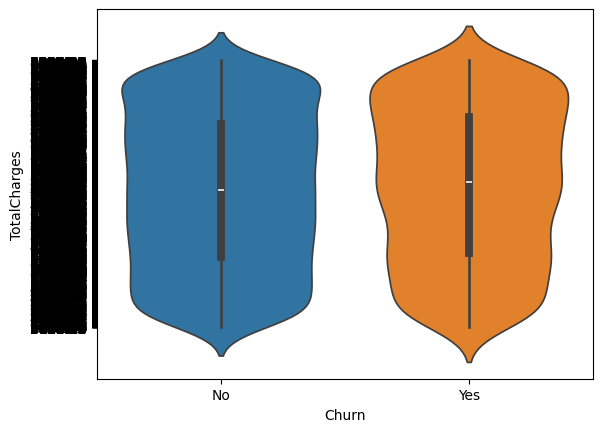

In [8]:
sns.violinplot(x='Churn', y='TotalCharges', data=df, hue='Churn');

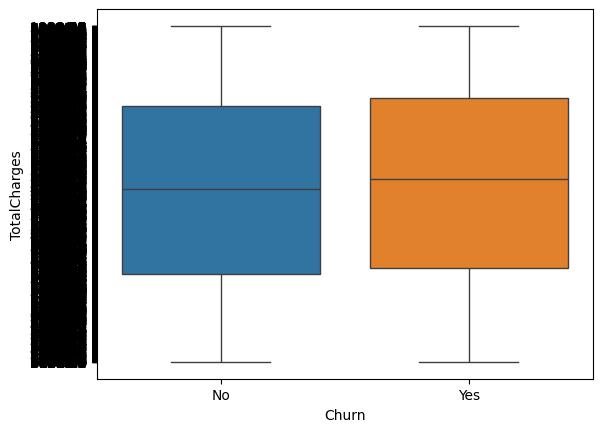

In [9]:
sns.boxplot(x='Churn', y='TotalCharges', data=df, hue='Churn');

## Здесь также видно, перекос данных и несбалансированность значений. Выбросов значительных не наблюдается

## Построим график boxplot с распределением колонки TotalCharges для различных типов контрактов

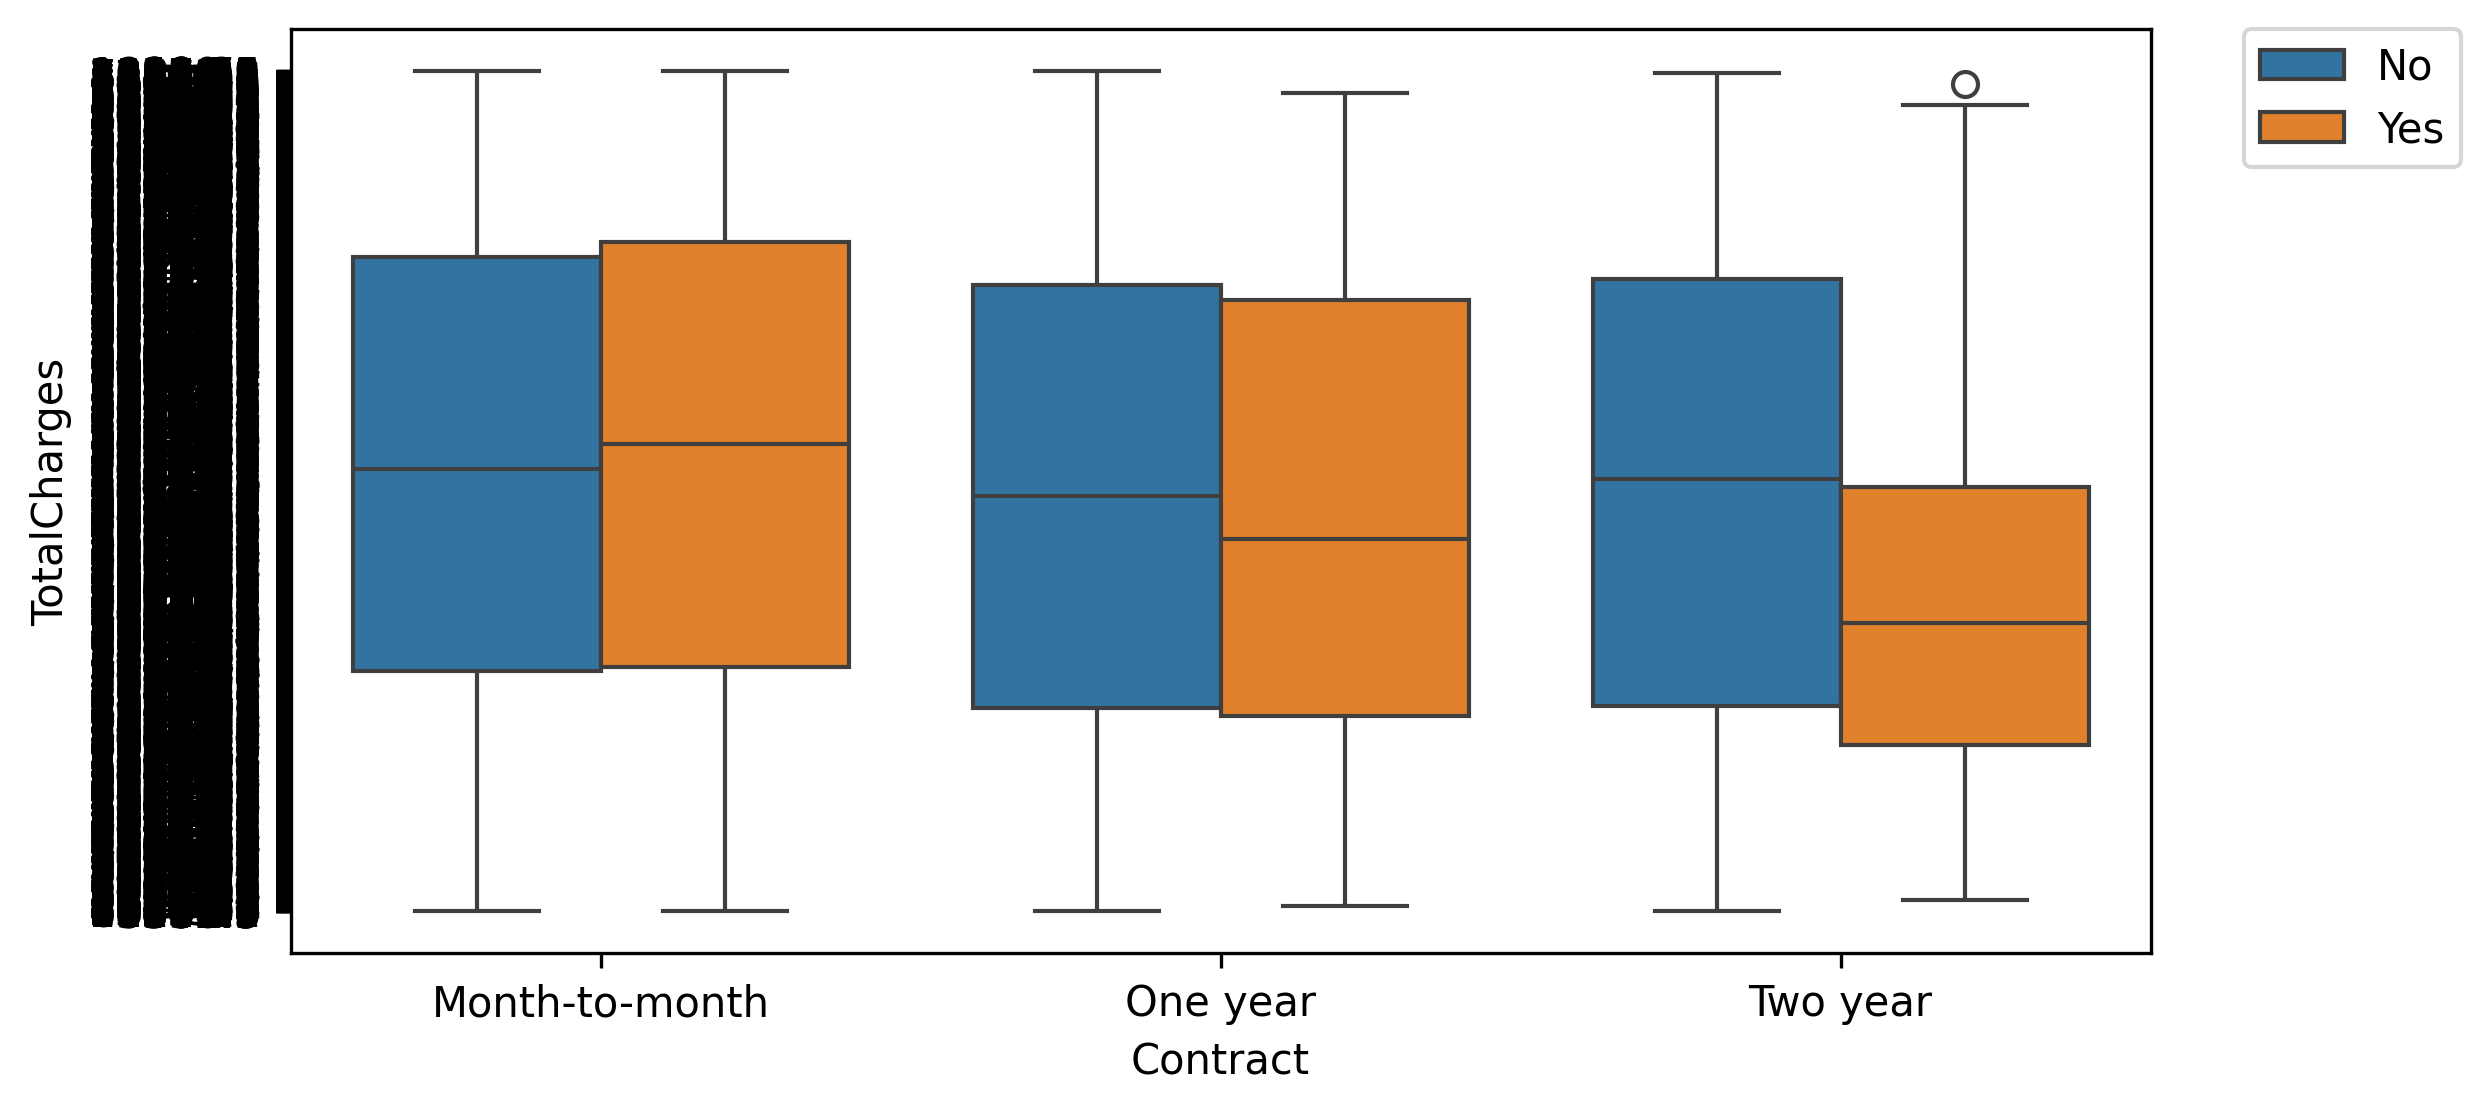

In [11]:
plt.figure(figsize=(8,4), dpi=300)
sns.boxplot(data=df, x='Contract', y='TotalCharges', hue='Churn')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2, borderaxespad=0.);

## Если мы посмотрим на тип контракта Month-to-month, то значение Churn в них примерно одинаковое. Почти такая же картина и для годовых контрактов, а вот для двухлетнего контракта видно, что меньше клиентов уходят в отток

## Теперь, подумаем, что могла бы сделать кампания Telco, чтобы меньше людей уходило в отток

## По вышеприведённым графикам видно, что чем больше значение TotalCharges(общие расходы) на любые виды контрактов, тем больше клиентов уходят в отток, и либо находят выгодные условия у конкурентов или, к примеру, не получают качественный сервис обслуживания в кампании Telco. Данный факт следует взять на вооружение

## Стоит задуматься над тем также, что почему при больших расходов большая часть клиентов не уходят в отток.

## Построим график bairplot с корреляцией числовыми признаками с целевой переменной(Churn). Для категориальных признаков проведём конвертацию их в дамми-переменные, так как корреляция вычисляется только для числовых колонок

In [12]:
corr_df = pd.get_dummies(df[['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
                             'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'InternetService',
                             'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']]).corr()

In [13]:
corr_df

,SeniorCitizen,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,Dependents_Yes,PhoneService_No,PhoneService_Yes,MultipleLines_No,...,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_No,Churn_Yes
SeniorCitizen,1.000000,0.001874,-0.001874,-0.016479,0.016479,0.211185,-0.211185,-0.008576,0.008576,-0.136213,...,-0.046262,-0.117000,-0.156530,0.156530,-0.016159,-0.024135,0.171718,-0.153477,-0.150889,0.150889
gender_Female,0.001874,1.000000,-1.000000,-0.001808,0.001808,0.010517,-0.010517,-0.006488,0.006488,-0.004476,...,-0.008026,0.003695,-0.011754,0.011754,0.016024,-0.001215,-0.000752,-0.013744,-0.008612,0.008612
gender_Male,-0.001874,-1.000000,1.000000,0.001808,-0.001808,-0.010517,0.010517,0.006488,-0.006488,0.004476,...,0.008026,-0.003695,0.011754,-0.011754,-0.016024,0.001215,0.000752,0.013744,0.008612,-0.008612
Partner_No,-0.016479,-0.001808,0.001808,1.000000,-1.000000,0.452676,-0.452676,0.017706,-0.017706,0.129929,...,-0.082783,-0.248091,-0.014877,0.014877,-0.110706,-0.082029,0.083852,0.095125,-0.150448,0.150448
Partner_Yes,0.016479,0.001808,-0.001808,-1.000000,1.000000,-0.452676,0.452676,-0.017706,0.017706,-0.129929,...,0.082783,0.248091,0.014877,-0.014877,0.110706,0.082029,-0.083852,-0.095125,0.150448,-0.150448
Dependents_No,0.211185,0.010517,-0.010517,0.452676,-0.452676,1.000000,-1.000000,-0.001762,0.001762,-0.023198,...,-0.068368,-0.204613,-0.111377,0.111377,-0.052021,-0.060267,0.150642,-0.059071,-0.164221,0.164221
Dependents_Yes,-0.211185,-0.010517,0.010517,-0.452676,0.452676,-1.000000,1.000000,0.001762,-0.001762,0.023198,...,0.068368,0.204613,0.111377,-0.111377,0.052021,0.060267,-0.150642,0.059071,0.164221,-0.164221
PhoneService_No,-0.008576,-0.006488,0.006488,0.017706,-0.017706,-0.001762,0.001762,1.000000,-1.000000,-0.315431,...,0.002791,-0.003519,0.016505,-0.016505,-0.007556,0.007721,-0.003062,0.003319,0.011942,-0.011942
PhoneService_Yes,0.008576,0.006488,-0.006488,-0.017706,0.017706,0.001762,-0.001762,-1.000000,1.000000,0.315431,...,-0.002791,0.003519,-0.016505,0.016505,0.007556,-0.007721,0.003062,-0.003319,-0.011942,0.011942
MultipleLines_No,-0.136213,-0.004476,0.004476,0.129929,-0.129929,-0.023198,0.023198,-0.315431,0.315431,1.000000,...,0.002098,-0.102937,0.151864,-0.151864,-0.070178,-0.063921,-0.080836,0.222605,0.032569,-0.032569


In [15]:
corr_yes_churn = corr_df['Churn_Yes'].sort_values().iloc[1:-1]
# corr_df['Churn_Yes']
# corr_df — это DataFrame, содержащий корреляции между признаками и целевой переменной.
# corr_df['Churn_Yes'] — это столбец, содержащий корреляции между всеми признаками и целевой переменной Churn_Yes (вероятность оттока клиента).
# .sort_values()
# Этот метод сортирует значения в столбце Churn_Yes по возрастанию.
# После сортировки корреляции будут упорядочены от наименьшей к наибольшей.
# .iloc[1:-1]
# .iloc — это метод для выборки строк по их индексу.
# [1:-1] — это срез, который:
# Исключает первую строку (1: — начинается со второй строки).
# Исключает последнюю строку (:-1 — заканчивается предпоследней строкой).

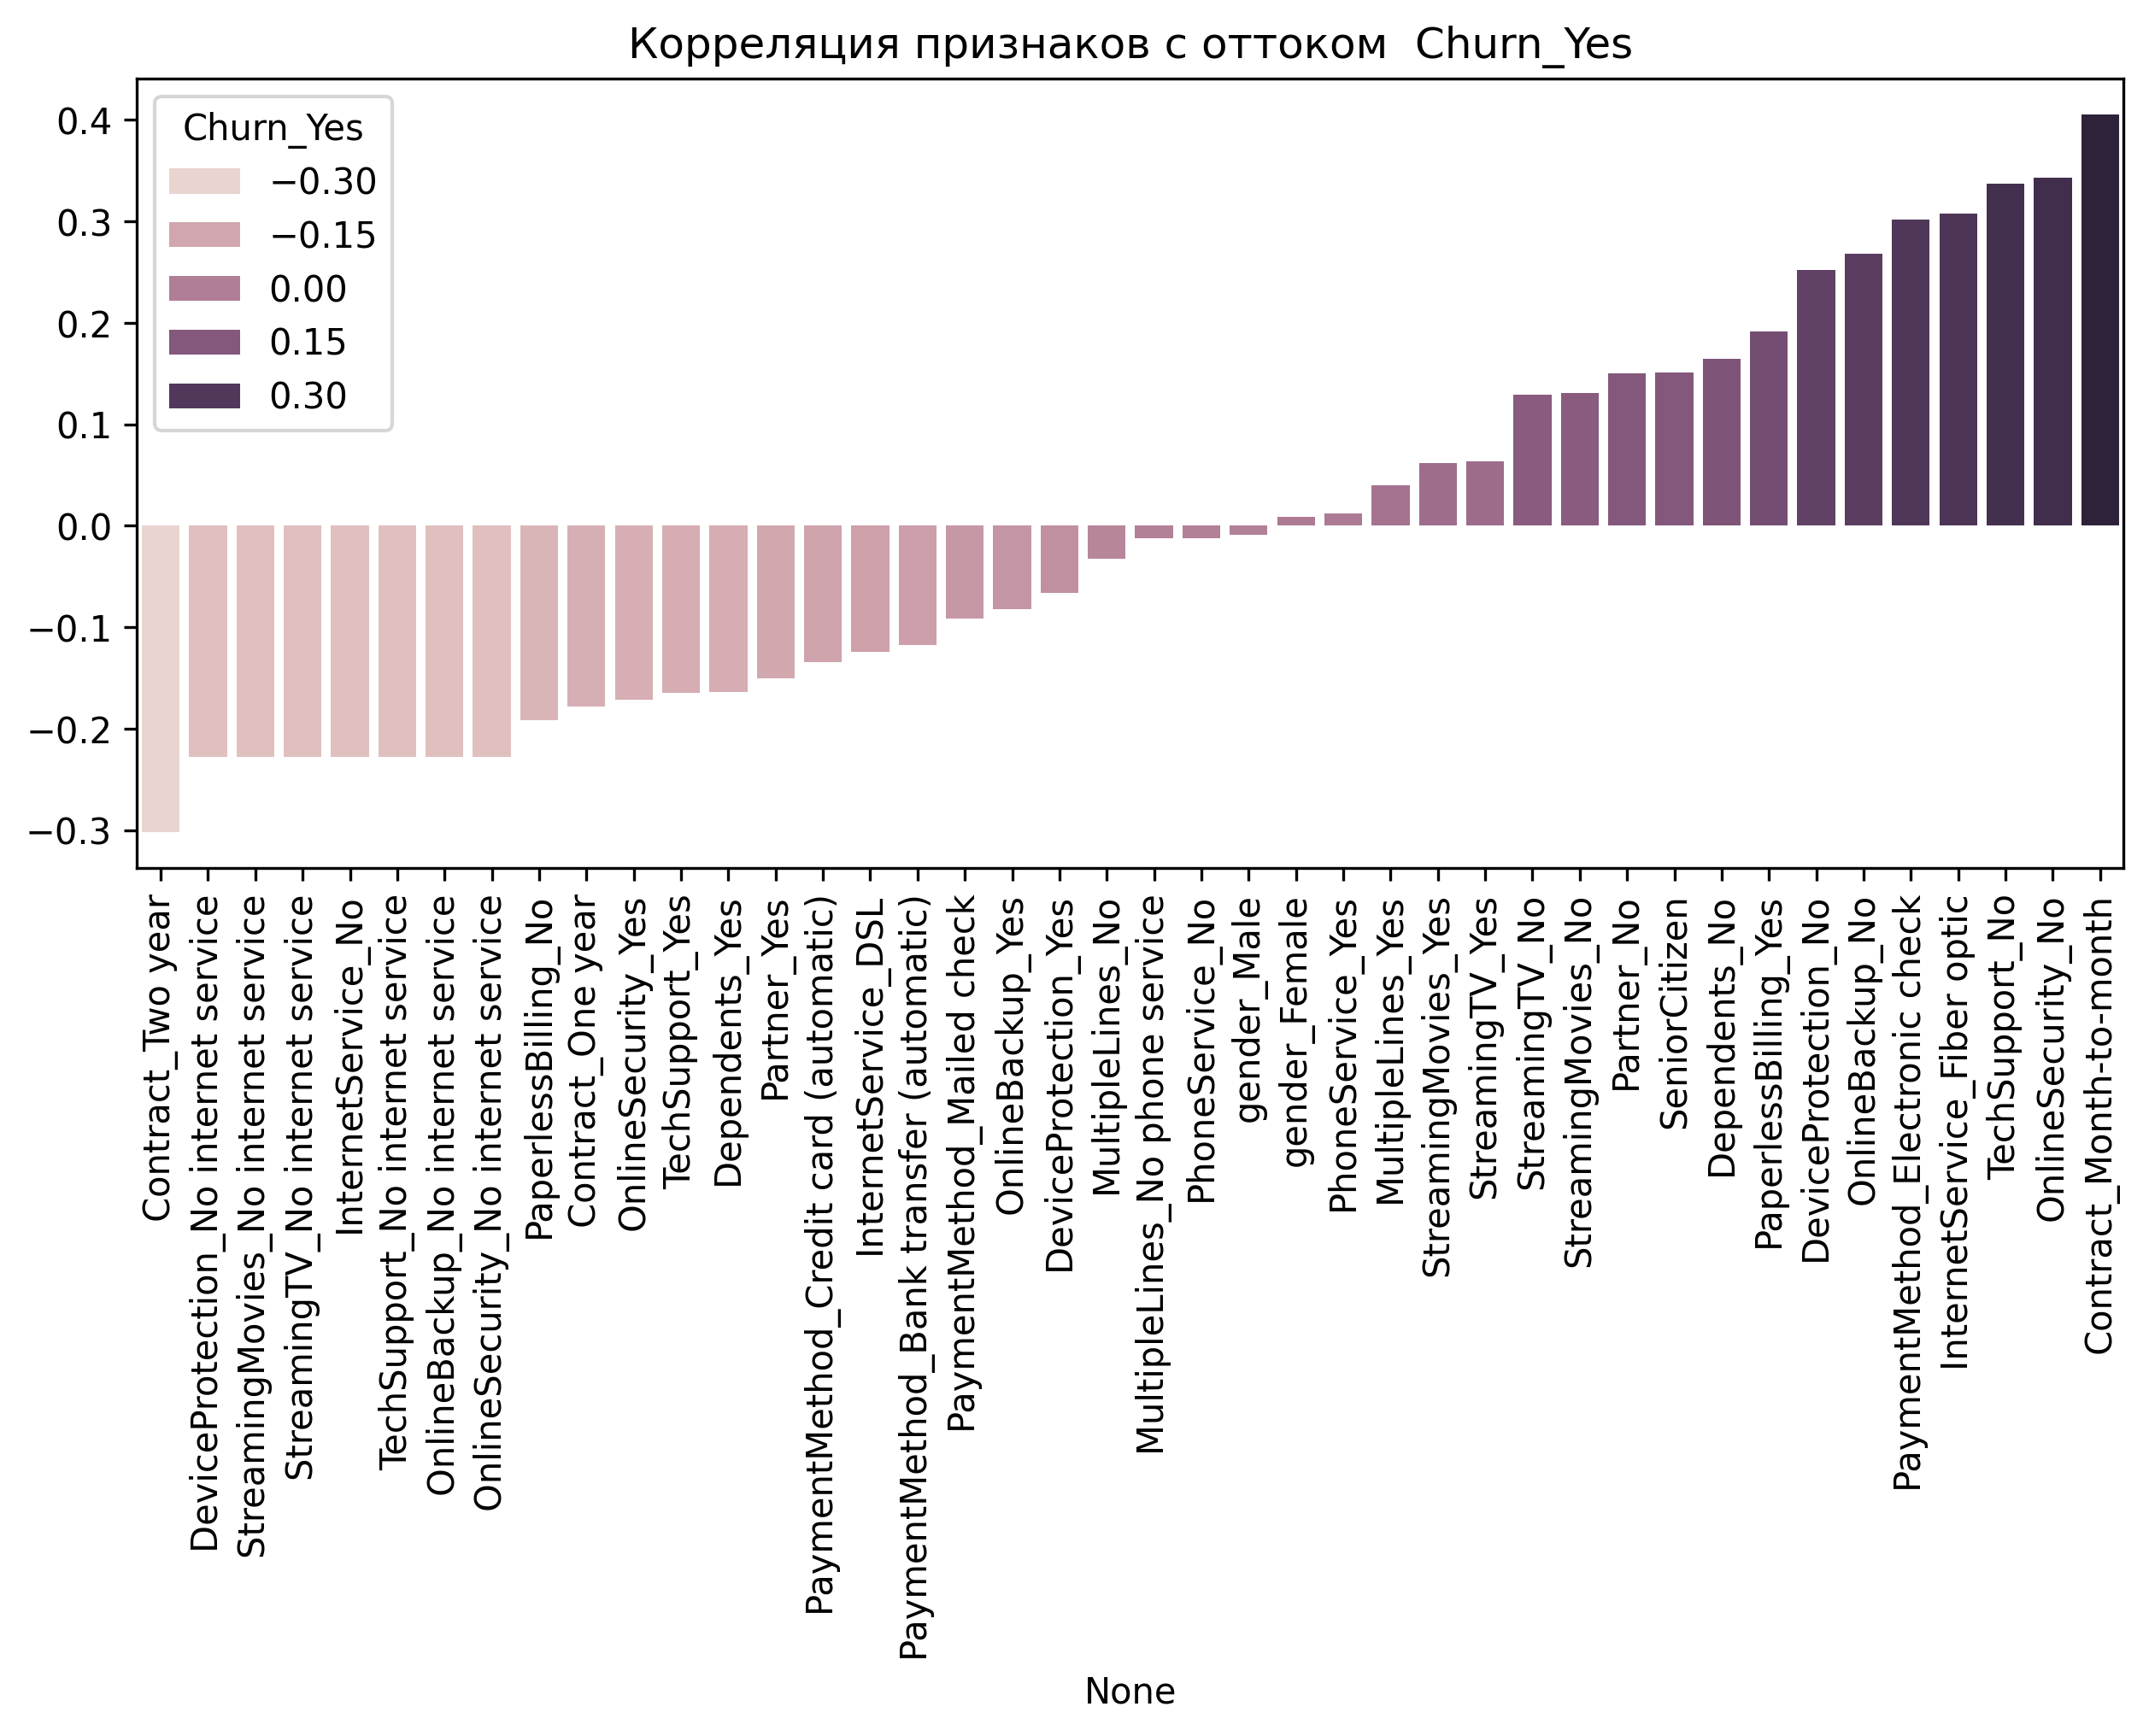

In [16]:
plt.figure(figsize=(10,4), dpi=300)
plt.title('Корреляция признаков с оттоком  Churn_Yes')
sns.barplot(x=corr_yes_churn.index, y=corr_yes_churn.values, hue=corr_yes_churn)
plt.xticks(rotation=90);

## График корреляции показал, что для краткосрочных контрактов с большими расходами характерен высокий отток клиентов

## Проведём анализ оттока и когорт.

## Разобьём всех абонентов(клиентов) на отдельные сегменты по длительности обслуживания в кампании Telco. Это нам поможет понять, как меняется поведение клиентов в зависимости от срока обслуживания

## Посмотрим какие у нас есть виды контрактов

In [17]:
df['Contract'].unique()

array(['Month-to-month', 'One year', 'Two year'], dtype=object)

In [38]:
df['Contract'].value_counts()

,count
Contract,
Month-to-month,3875
Two year,1695
One year,1473


## Помесячный контракт доминирует:

Более половины клиентов (55%) используют помесячный контракт. Это говорит о том, что большинство клиентов предпочитают гибкость и не хотят быть привязанными к долгосрочным обязательствам.

Долгосрочные контракты:

Двухгодичный контракт (24%) и годовой контракт (21%) менее популярны, но всё же имеют значительную долю.

Клиенты с долгосрочными контрактами, вероятно, более лояльны, так как они связаны обязательствами.

In [37]:
df['tenure'].unique()

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [36]:
df['tenure'].value_counts()

,count
tenure,
1,613
72,362
2,238
3,200
4,176
...,...
28,57
39,56
44,51


## Построим гистограмму с распределением значений колонки tenure - это количество месяцев, сколько времени человек является(или являлся) абонентом кампании.

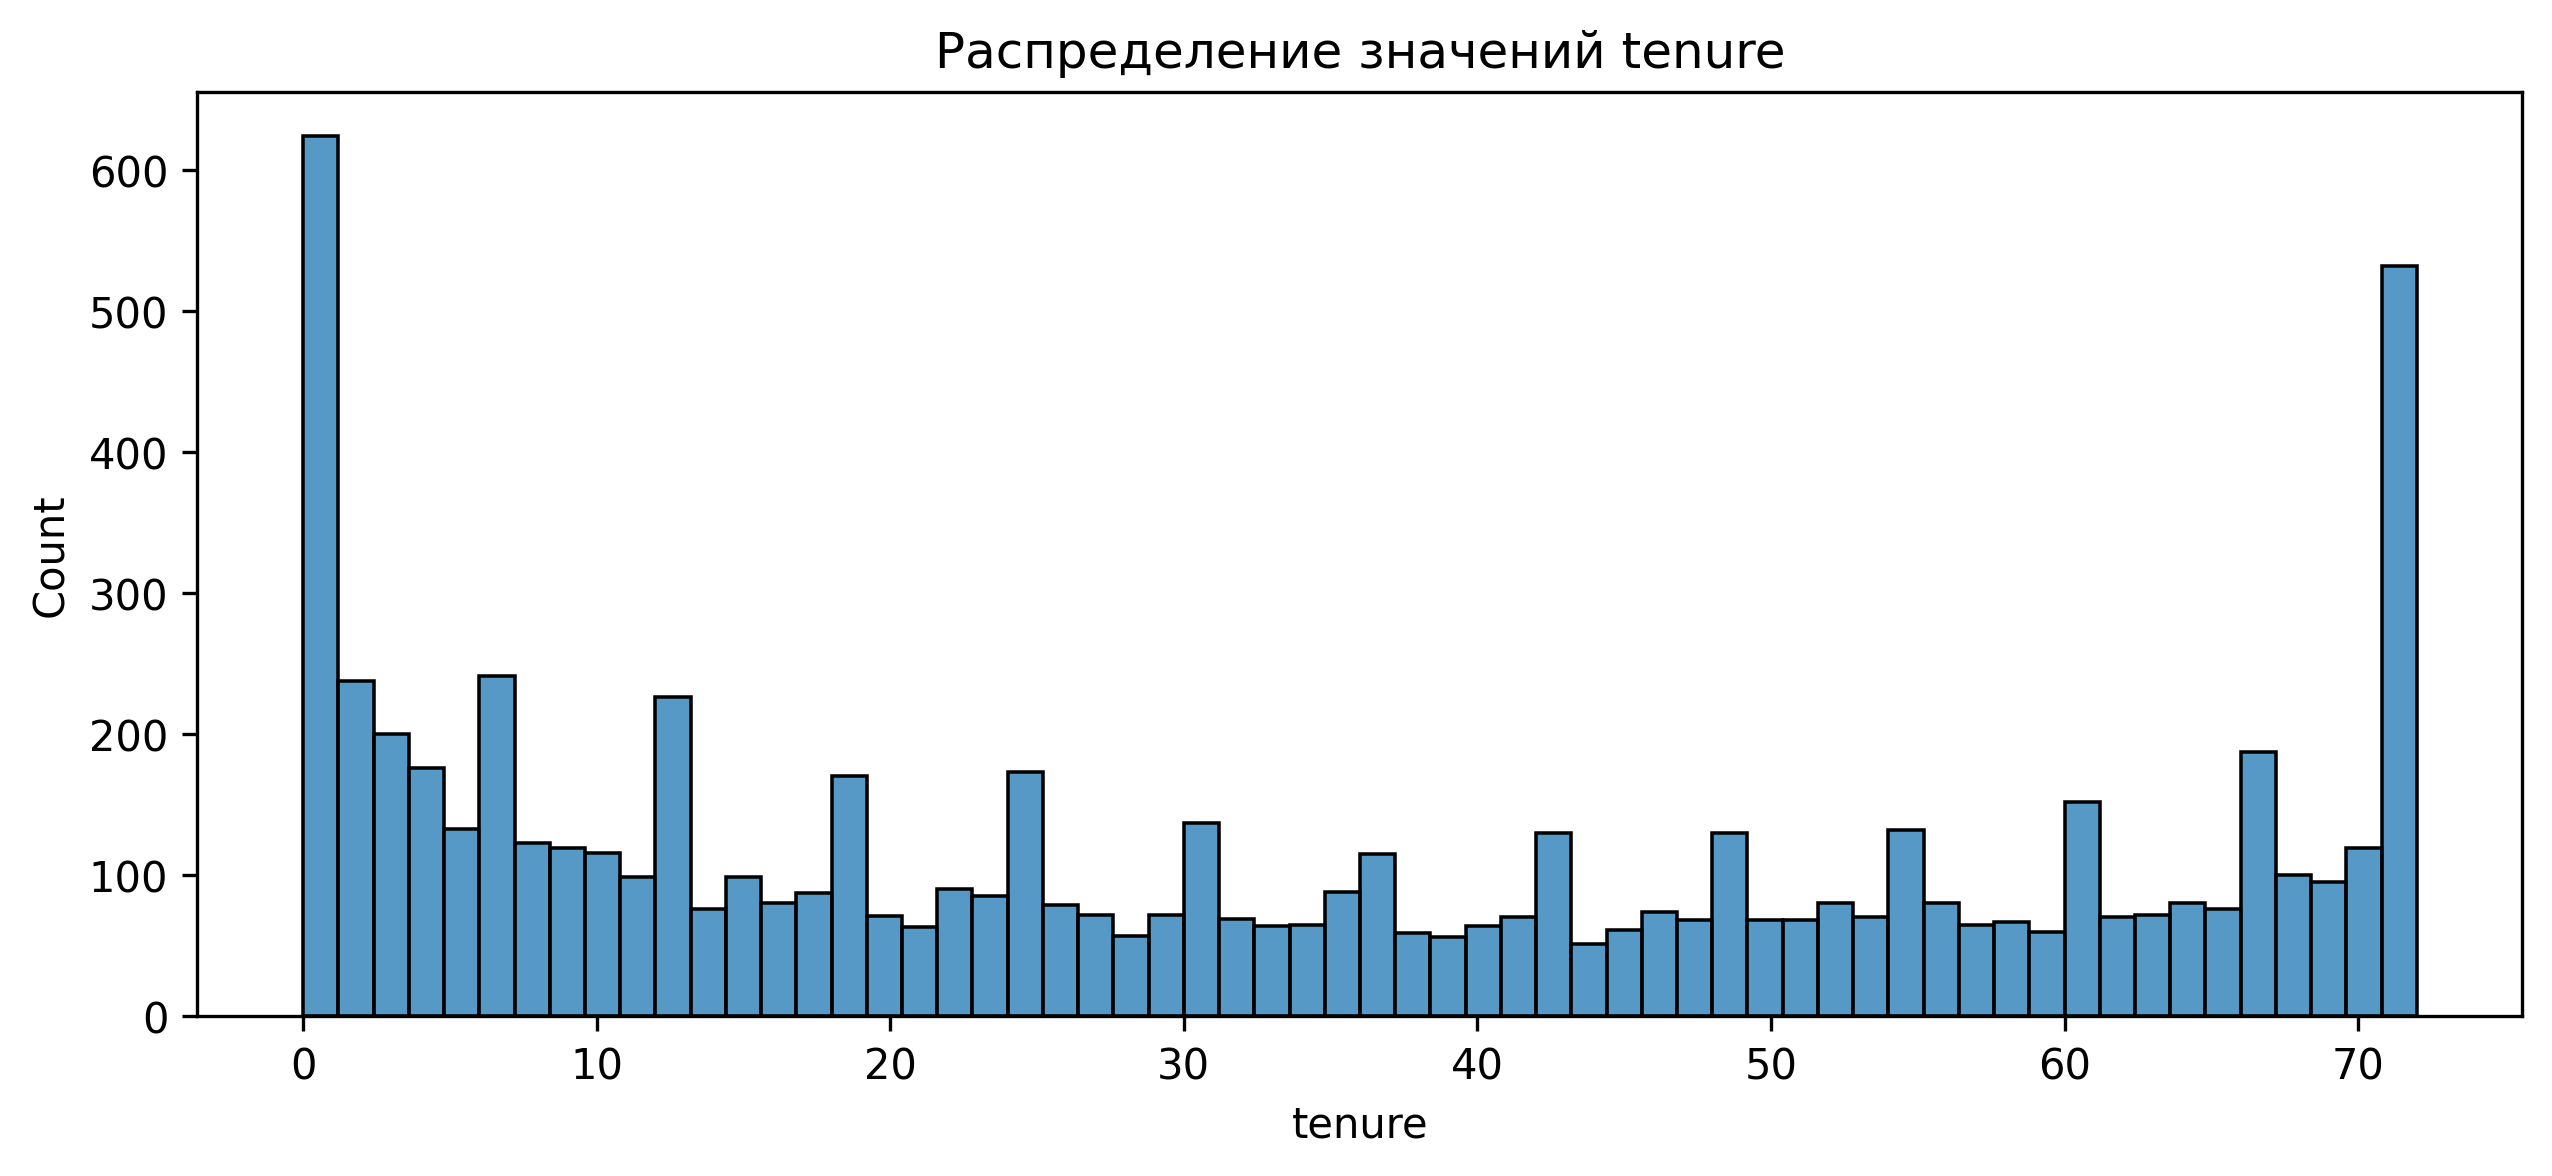

In [21]:
plt.figure(figsize=(10,4), dpi=300)
plt.title('Распределение значений tenure')
sns.histplot(data=df, x='tenure', bins=60);

## Видно, что очень много клиентов имеют значение 'tenure' от 1 до 2 месяцев. Второе пиковое значение находится в районе 72 и заметны на графике всплески, что скорее означает продление годовых или двухлетних контрактов

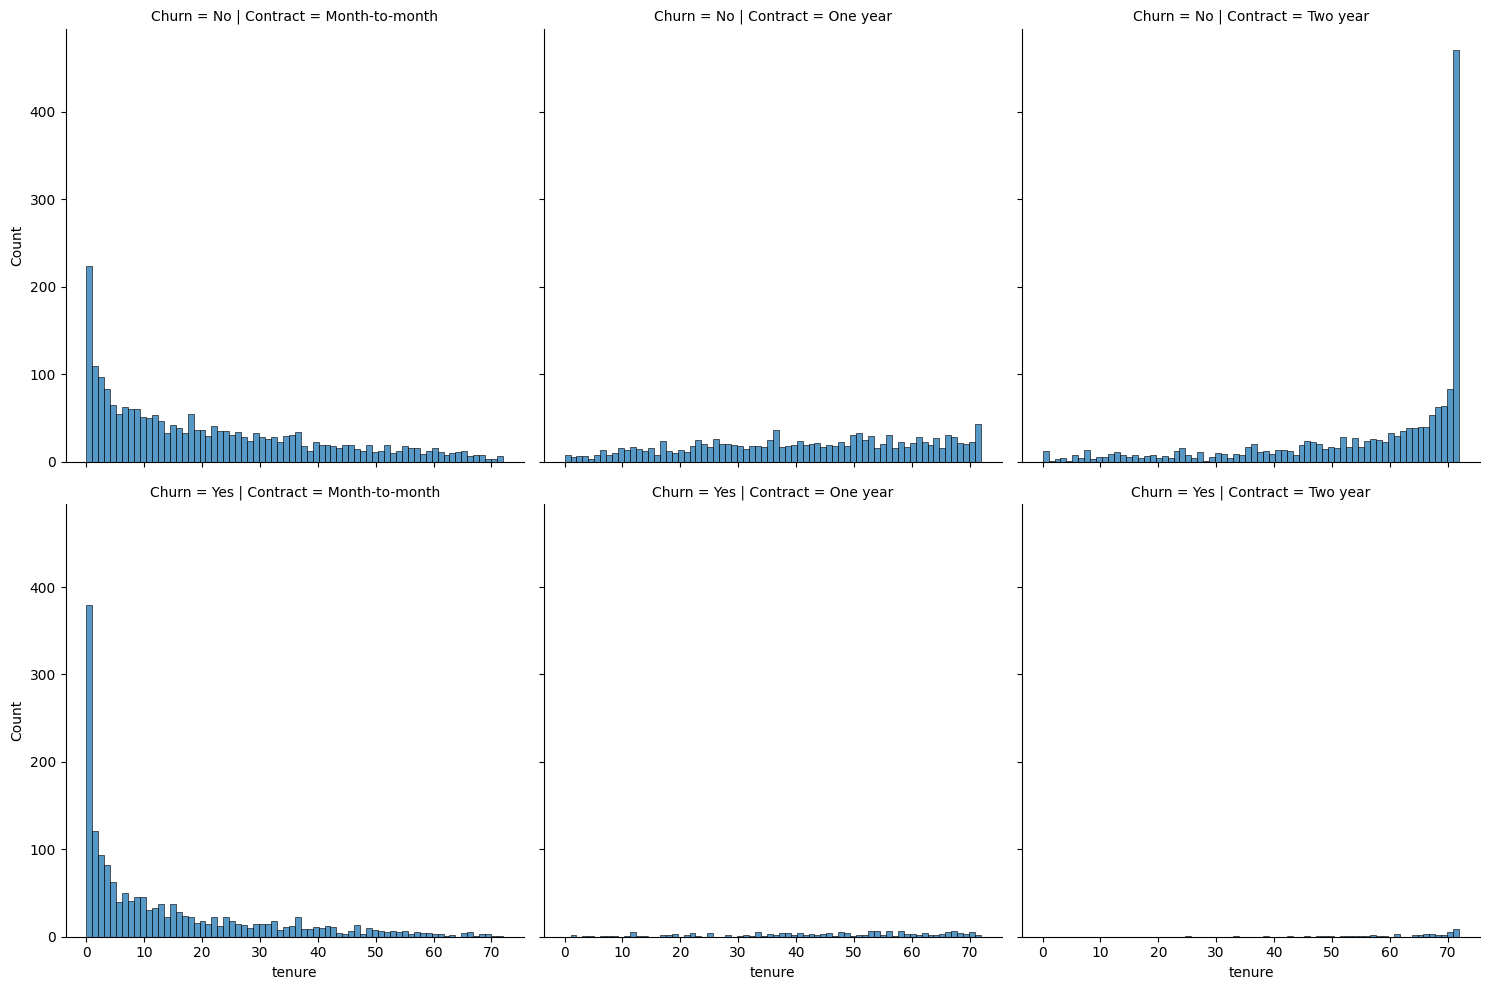

In [22]:
#plt.title('Распределение значений tenure')
sns.displot(data=df, x='tenure', bins=70, col='Contract', row='Churn')
plt.show();

## По графику displot видно, что на годовых и двугодовых контрактах, уходящих в отток клиентов мало, поэтому основные усилия можно направить на контракты 'Month-to-month'. Причём для краткосрочных контрактов(меньше года) пик значения, наблюдается от 1 до 2 месяцев для клиентов уходящих в отток. Но затем идёт пологое распределение. Следует учесть тот факт, что ранее мы наблюдали большой отток клиентов из-за больших расходов на долгосрочных контрактах. Возможно, отток на контрактах 'Month-to-month' обусловлен из за высоких цен(стоимость тарифа) чем на долгосрочных контрактах. В таком случае кампании Telco следовало бы проводить активную маркетинговую акцию, т.е. предлагать клиентам с контрактом 'Month-to-month' перейти на годовые или двугодовые контракты, тем самым доход от этих абонентов снизится, но в долгосрочной перспективе кампания получит больший суммарный доход от этого абонента.

## Построим график scatterplot для колонок Total Charges и Monthly Charges, колонки раскрашим по колонке Churn

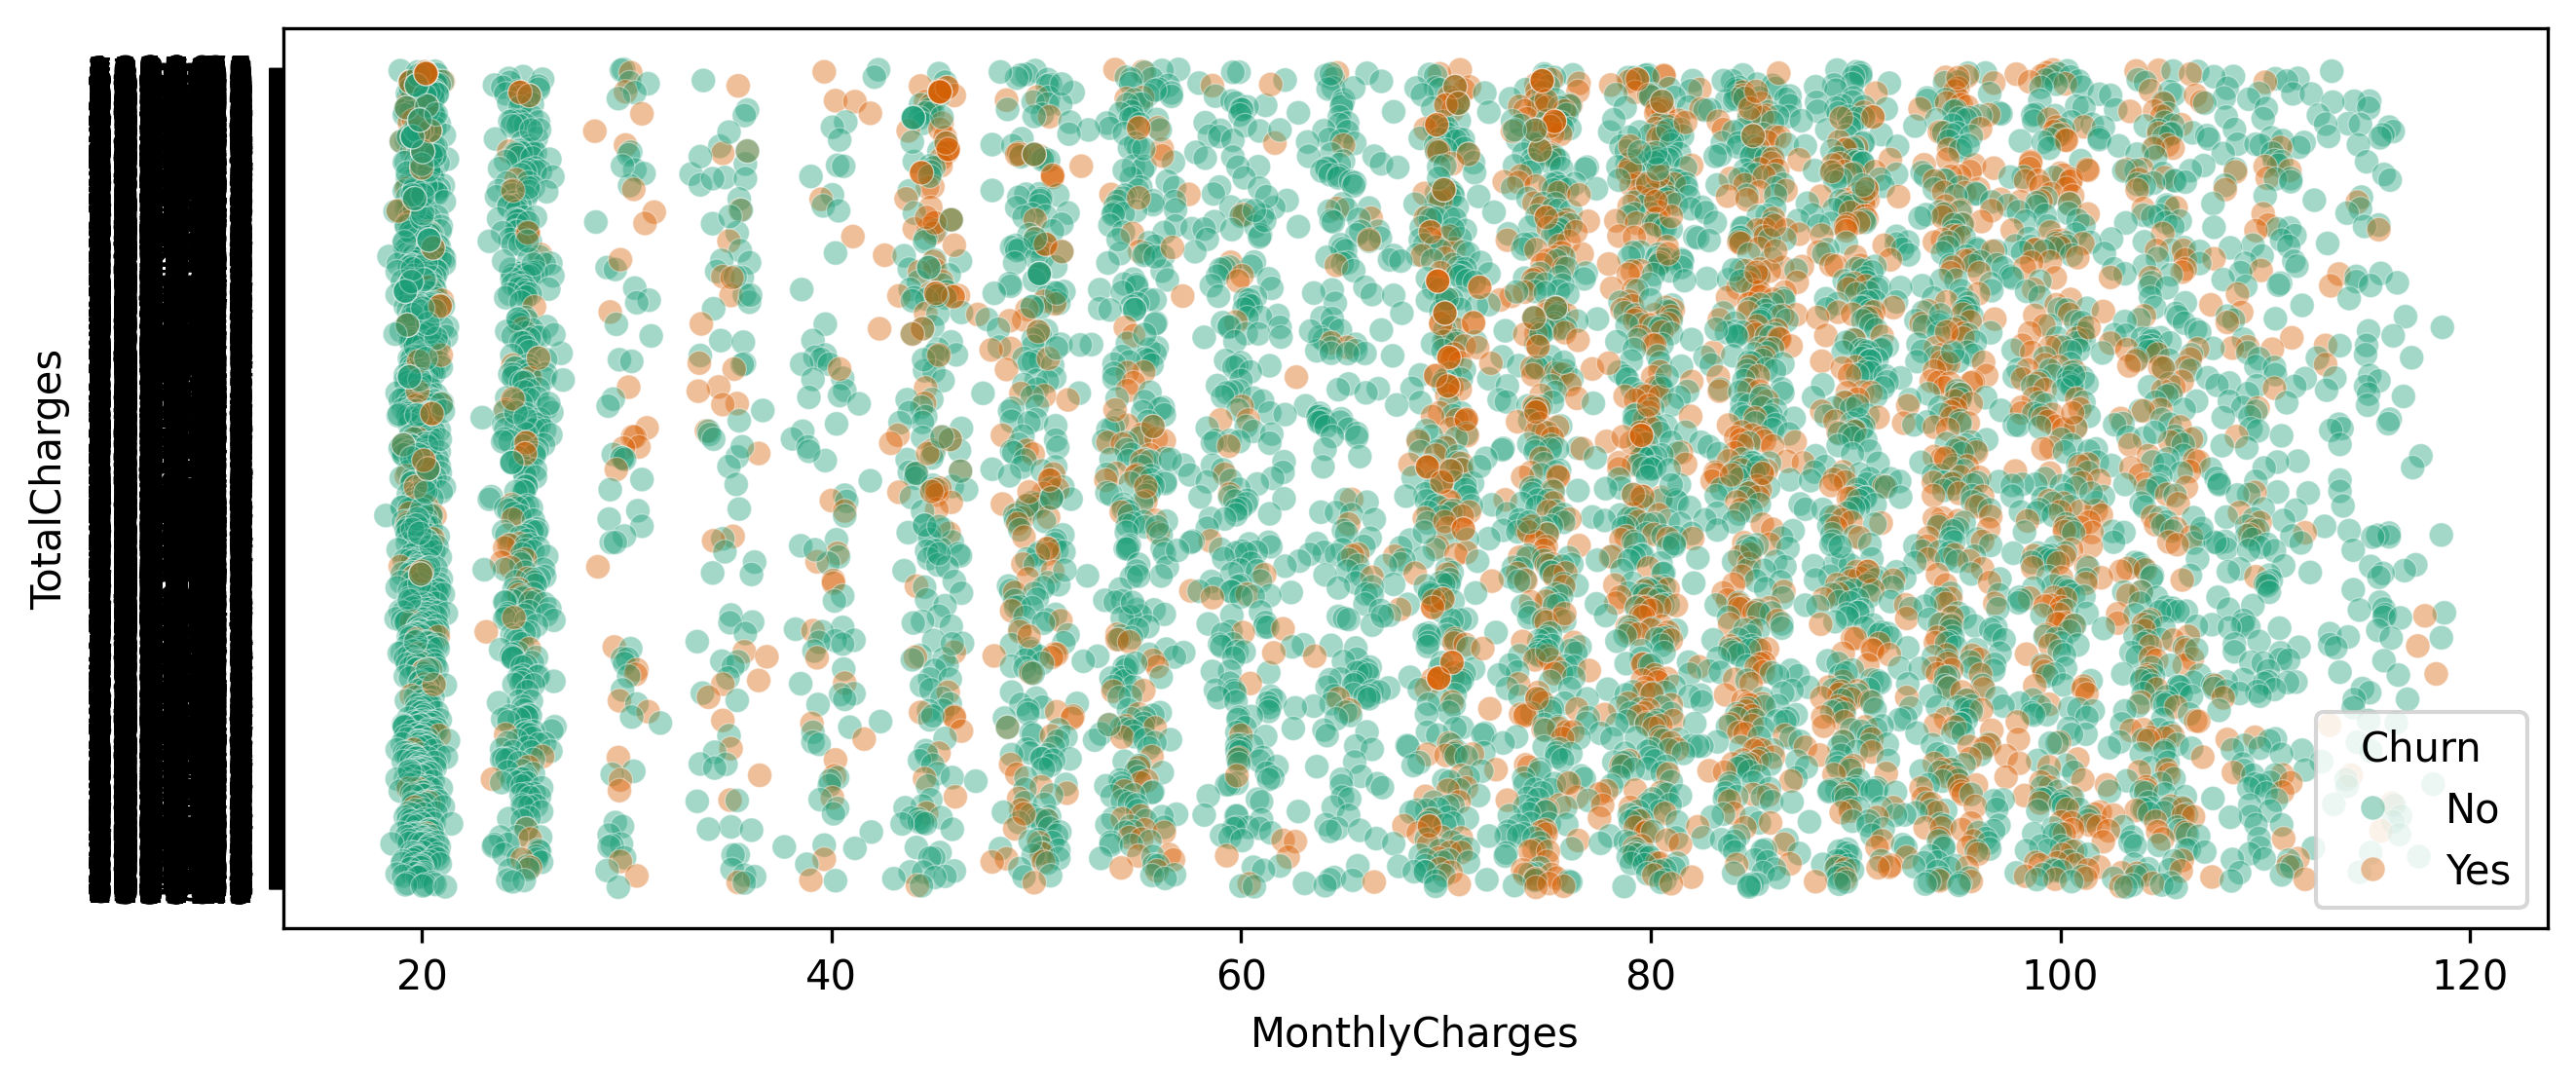

In [28]:
plt.figure(figsize=(10,4), dpi=300)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Churn', alpha=0.4, linewidth=0.3, palette='Dark2');

## Очередной раз подтверждается тот факт, что в отток уходят те, у кого большие расходы. В принципе, это логично, чем больше ежемесячные расходы, тем больше у клиентов возникает причин искать более дешёвые тарифы у конкурентов

## Да, и вообще, это очень дискуссионный вопрос: "Что для кампании важнее; либо абонент с ежемесячными высокими платежами(MonthlyCharges), либо абонент с восыкими общими платежами(TotalCharges)". Эти два показателя связаны между собой через длительность по времени(tenure)

## На графике scatterplot мы подтверждаем, что в отток уходят клиенты с высокими ежемесячными расходами, причём в основном у них небольшие значения(TotalCharges).

## СОЗДАНИЕ КОГОРТ (СЕГМЕНТОВ) ПО КОЛОНКЕ Tenure

## Для начала поместим различные значения tenure (1 месяц, 2 месяц, 3 месяца и так далее) в отдельные когорты (сегменты).

## Для каждого уникального значения колонки tenure в качестве когорты, вычислим процент оттока (churn rate) - это количество тех людей, кто ушёл в отток в когорте, как процент от общего количества людей в данной когорте. Вычислим такой процент отдельно для каждой когорты. В итоге должно получиться когорты от 1 до 72 месяцев, и с увеличением количества месяцев уровень оттока должен снижаться. Это разумно, потому что чем дольше клиент пользуется услугами кампании, тем вероятнее то, что его/её всё устраивает, и он/она продолжит пользоваться этими услугами

In [39]:
no_churn = df.groupby(['Churn', 'tenure']).count().transpose()['No']
no_churn

tenure,0,1,2,3,4,5,6,7,8,9,...,63,64,65,66,67,68,69,70,71,72
customerID,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
gender,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
SeniorCitizen,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
Partner,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
Dependents,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
PhoneService,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
MultipleLines,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
InternetService,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
OnlineSecurity,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356
OnlineBackup,11,233,115,106,93,69,70,80,81,73,...,68,76,67,76,88,91,87,108,164,356


In [40]:
yes_churn = df.groupby(['Churn', 'tenure']).count().transpose()['Yes']
yes_churn

tenure,1,2,3,4,5,6,7,8,9,10,...,63,64,65,66,67,68,69,70,71,72
customerID,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
gender,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
SeniorCitizen,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
Partner,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
Dependents,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
PhoneService,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
MultipleLines,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
InternetService,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
OnlineSecurity,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6
OnlineBackup,380,123,94,83,64,40,51,42,46,45,...,4,4,9,13,10,9,8,11,6,6


In [52]:
churn_rate = 100 * yes_churn / (no_churn + yes_churn)
churn_rate = churn_rate.drop(columns=[0])

In [53]:
churn_rate.transpose()

,customerID,gender,SeniorCitizen,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
tenure,,,,,,,,,,,,,,,,,,,
1,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212,61.990212
2,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672,51.680672
3,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000,47.000000
4,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091,47.159091
5,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301,48.120301
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
68,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
69,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053,8.421053
70,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697,9.243697


In [54]:
churn_rate.transpose()['customerID']

,customerID
tenure,
1,61.990212
2,51.680672
3,47.000000
4,47.159091
5,48.120301
...,...
68,9.000000
69,8.421053
70,9.243697


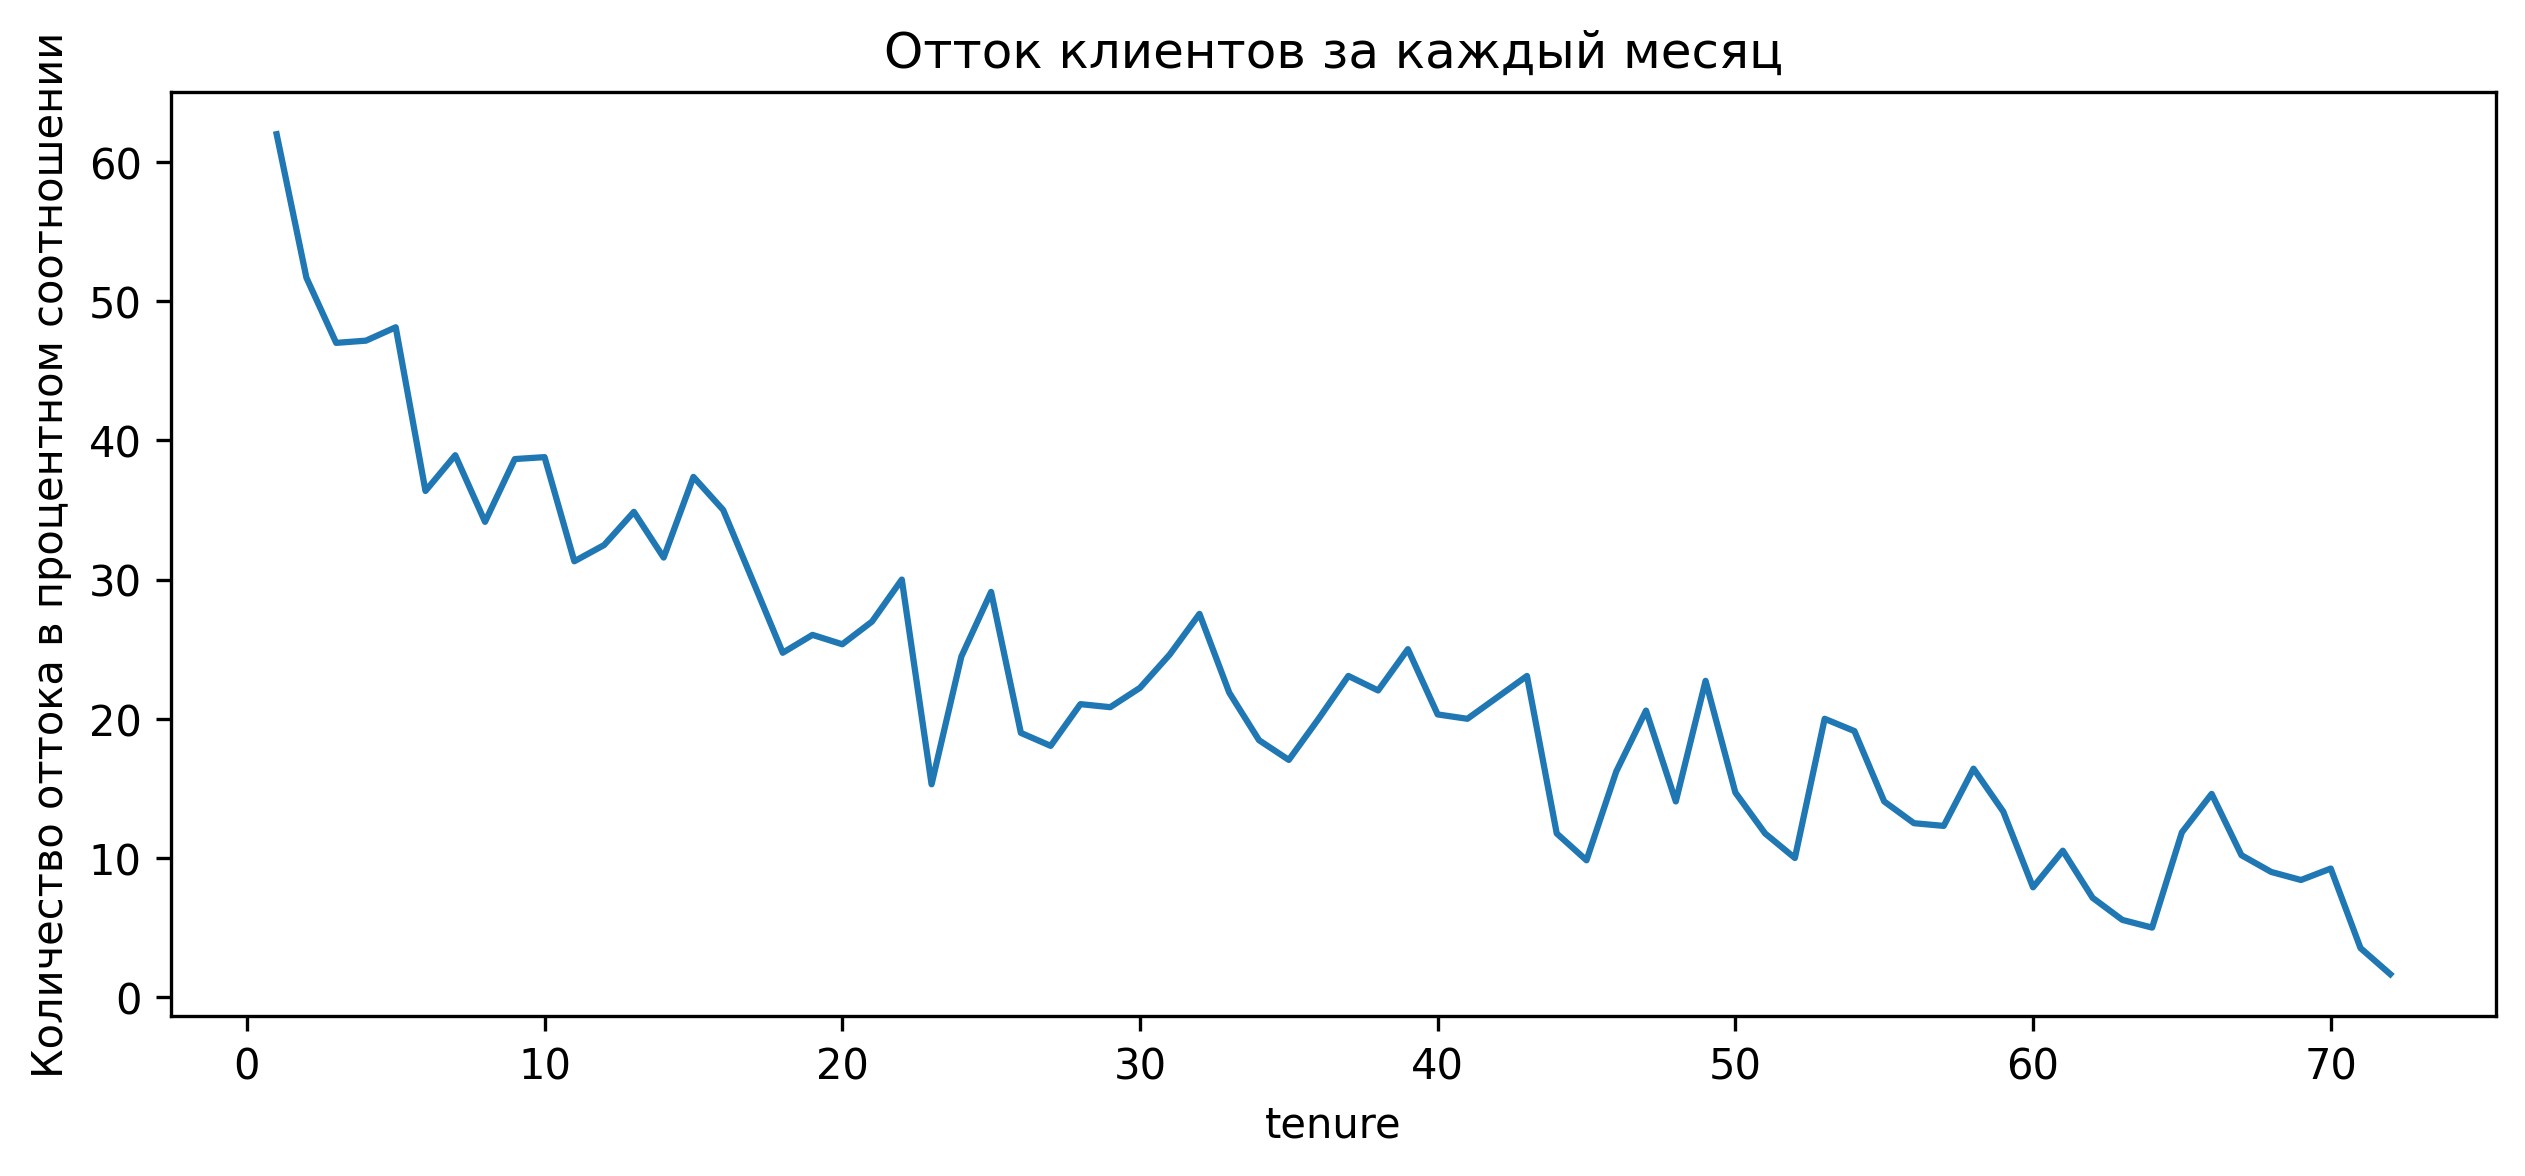

In [55]:
plt.figure(figsize=(10,4), dpi=300)
plt.title('Отток клиентов за каждый месяц')
plt.xlabel('Количество месяцев')
plt.ylabel('Количество оттока в процентном соотношении')
churn_rate.transpose()['customerID'].plot();

## Видно, что на графике пологое распределение. Чем больше значение tenure, тем меньше процент оттока в когорте

## Оптимизируем процесс исследования. На основе колонки tenure создадим колонку с названием 'Tenure Cohort', в которой будут следующие 4 категории:
- 0-12 месяцев
- 12-24 месяца
- 24-48 месяцев
- Более 48 месяцев

## Создадим функцию для преобразования данных

In [56]:
def cohort(tenure):
    if tenure < 13:
        return '0-12 месяцев'
    elif tenure < 25:
        return '12-24 месяцев'
    elif tenure < 49:
        return '24-48 месяцев'
    else:
        return 'Более 48 месяцев'

In [57]:
df['Tenure Cohort'] = df['tenure'].apply(cohort)

In [58]:
df[['Tenure Cohort', 'tenure']]

,Tenure Cohort,tenure
0,0-12 месяцев,1
1,24-48 месяцев,34
2,0-12 месяцев,2
3,24-48 месяцев,45
4,0-12 месяцев,2
...,...,...
7038,12-24 месяцев,24
7039,Более 48 месяцев,72
7040,0-12 месяцев,11
7041,0-12 месяцев,4


## Построим график scatterplot для Total Charges и Monthly Charges, раскрашивая график разными цветами по колонке 'Tenure Cohort', которую создали ранее

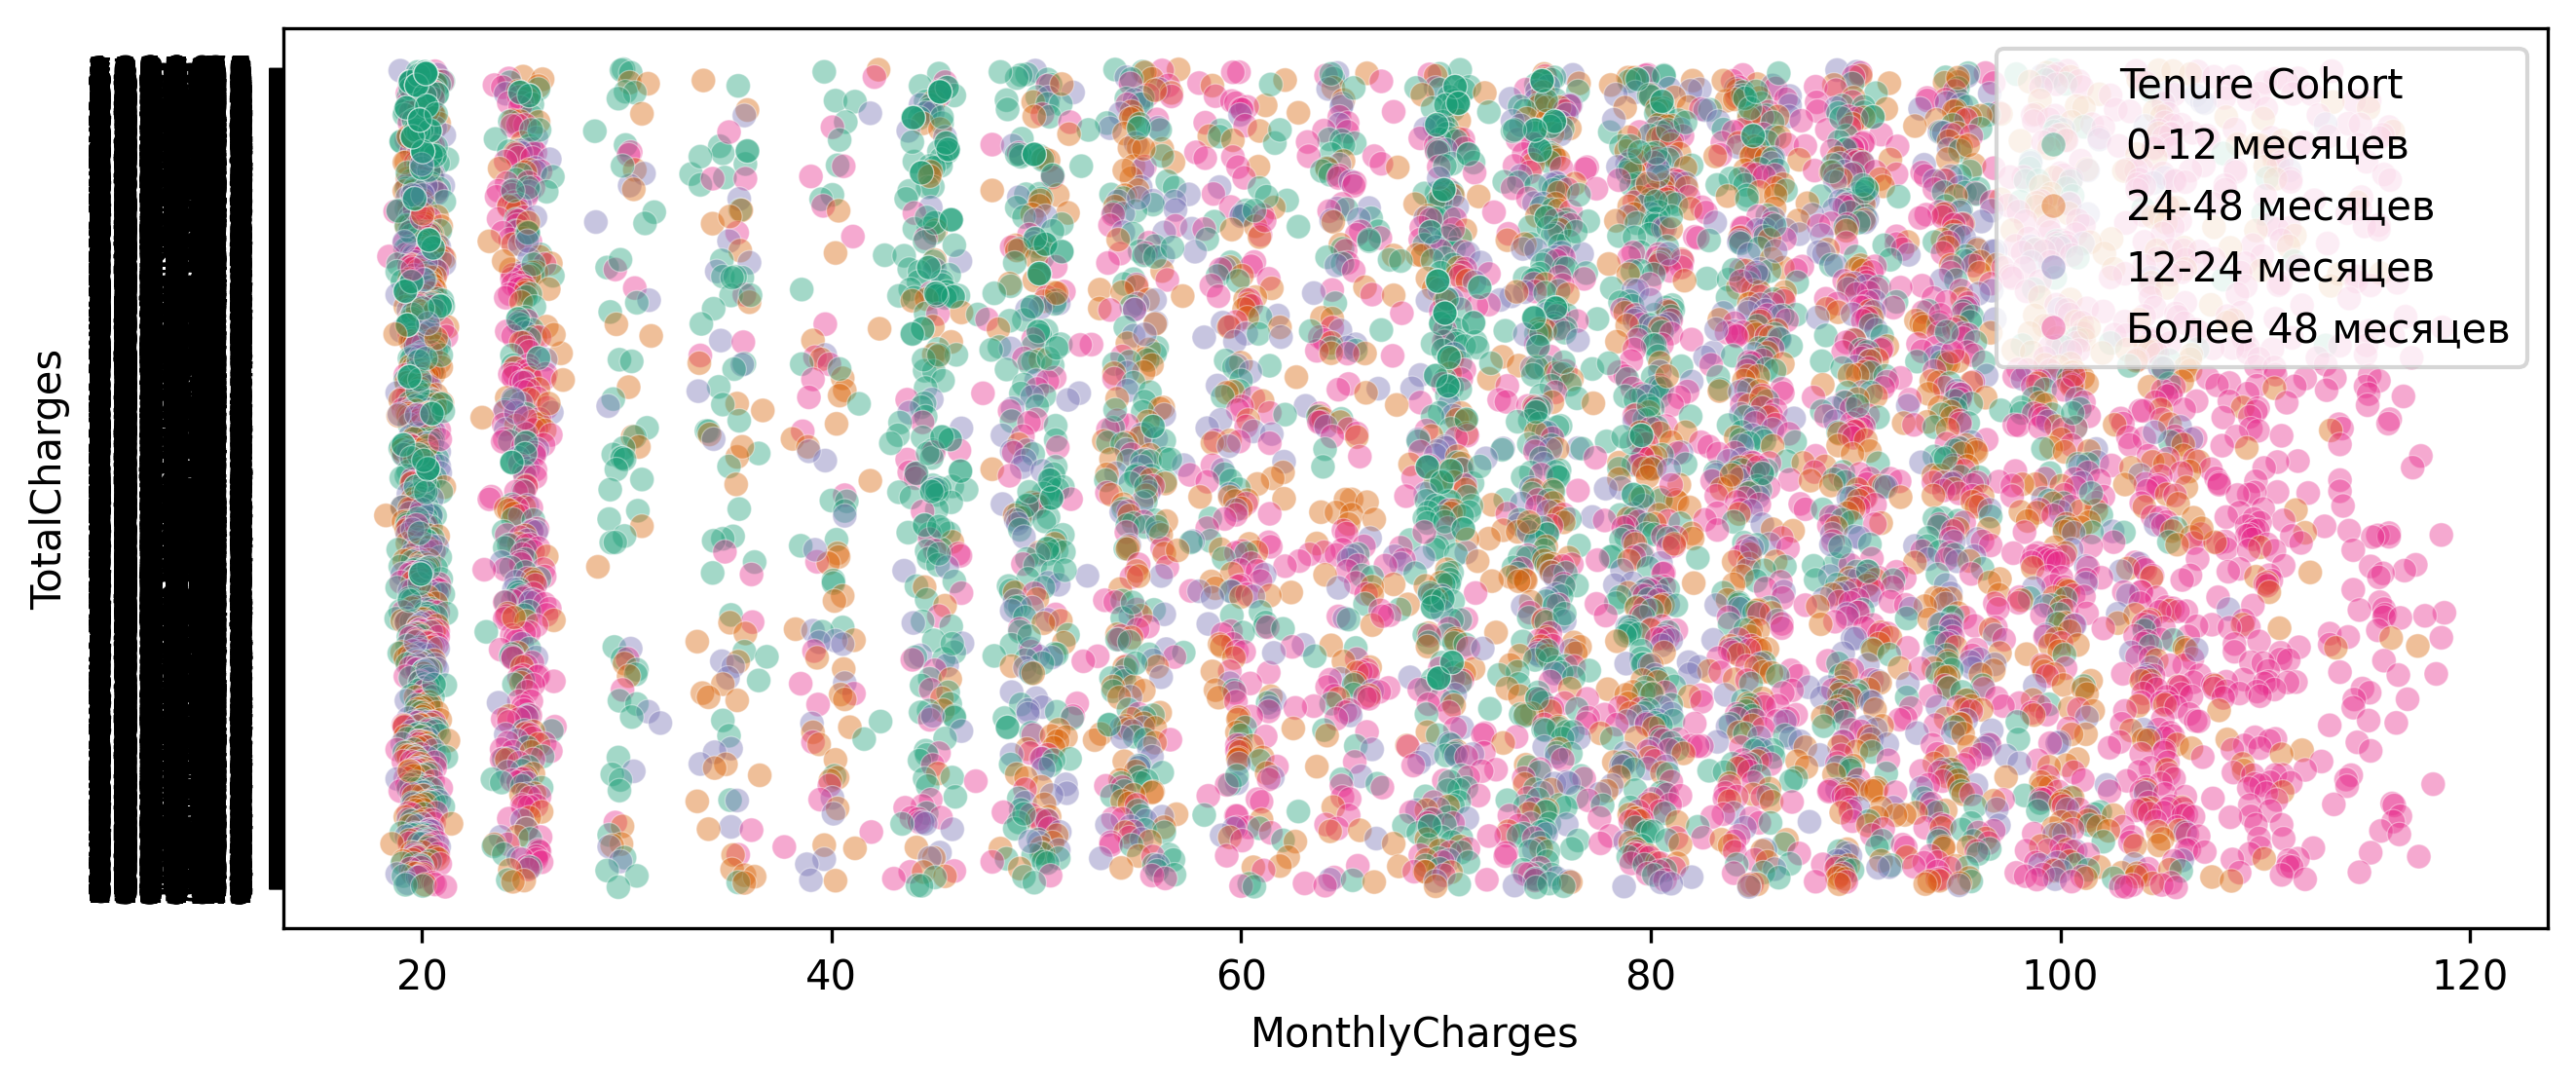

In [59]:
plt.figure(figsize=(10,4), dpi=300)
sns.scatterplot(data=df, x='MonthlyCharges', y='TotalCharges', hue='Tenure Cohort', alpha=0.4, linewidth=0.3, palette='Dark2');

## На рисунке всё выглядит логично. Чем больше когорта, тем большее значение 'TotalCharges' она принимает. Сам рисунок является более читаемым и легко воспринимаемым для анализа

## Построим график countplot с количеством ушедших и не ушедших в отток людей в каждой когорте

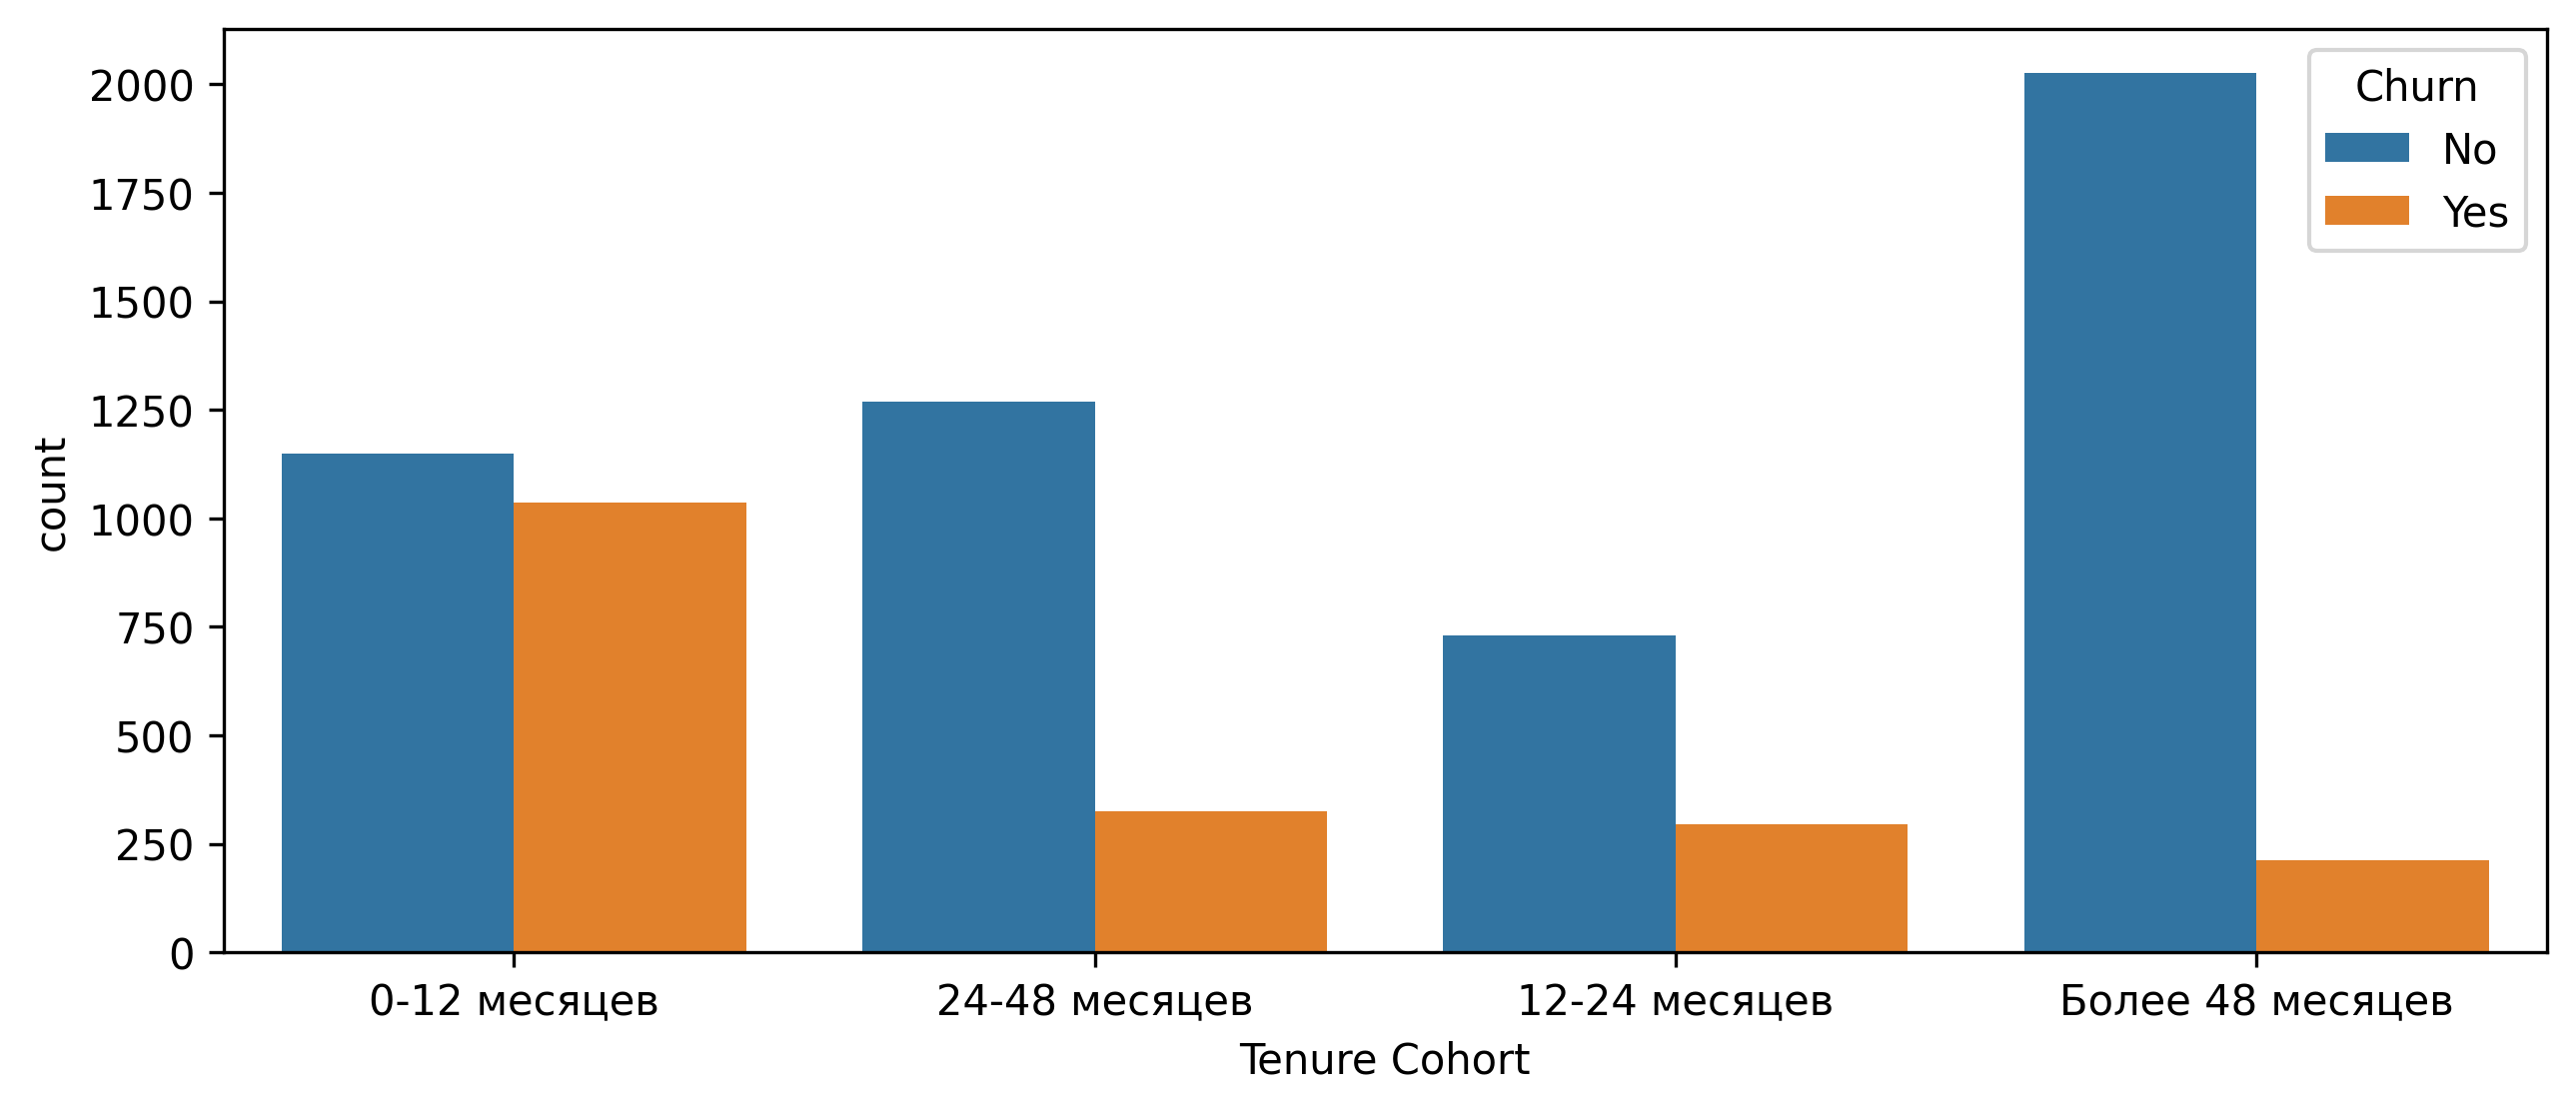

In [60]:
plt.figure(figsize=(10,4), dpi=300)
sns.countplot(data=df, x='Tenure Cohort', hue='Churn');

## Отчётливо видно, что клиенты с длительностью обслуживания более 48 месяцев менее подвержены к оттоку, а те кто пользуются услугами кампании менее 12 месяцев, то вероятность оттока заметно возрастает

## Создадим набор графиков CountPlot с количеством клиентов по различным когортам Tenure Cohort. Для каждого типа контракта создадим отдельный график, и раскрасим эти графики разными цветами по колонке Churn.

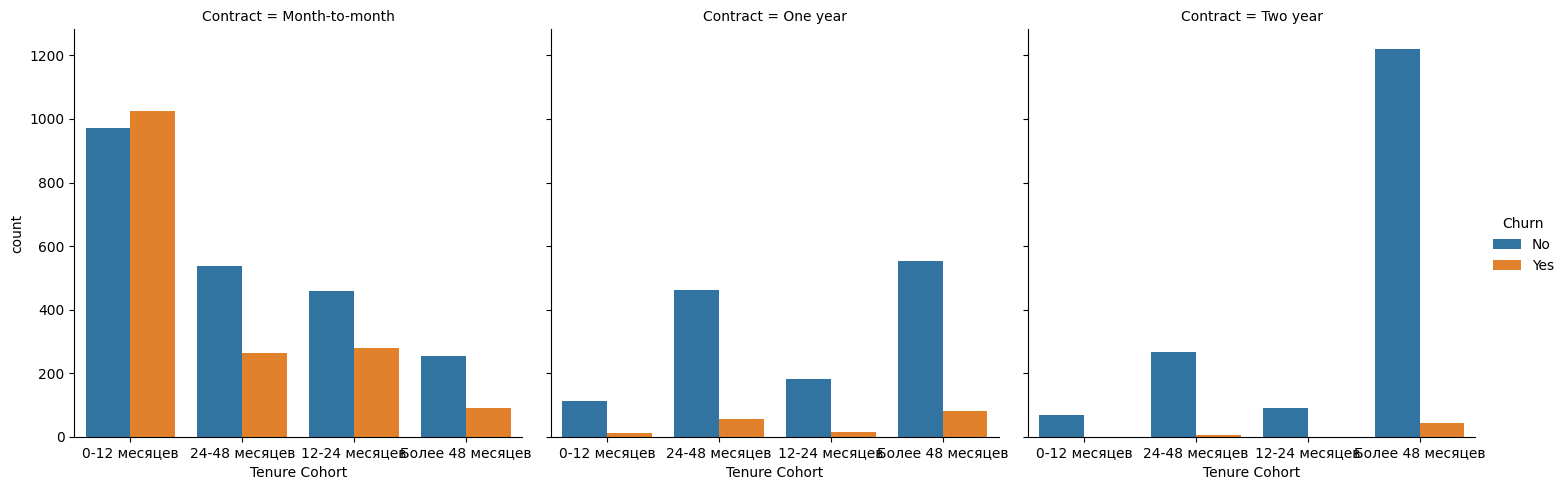

In [61]:
sns.catplot(data=df, x='Tenure Cohort', hue='Churn', kind='count', col='Contract');

## Вышеприведённый график, как и другие, также подтверждает тот факт, что клиенты на однолетнем и двухлетнем контрактах меньше уходят в отток вне зависимости от длительности пользования услугами

## ПЕРЕЙДЁМ К СОЗДАНИЮ ПРЕДИКТИВНОЙ МОДЕЛИ

## В нашем исследовании будем использовать модели машиного обучения с учителем. Исследуем 4 модели на основе деревьев: одно дерево решений, случайный лес, адаптивный бустинг и градиентный бустинг и сравним результаты.

## ОДНО ДЕРЕВО РЕШЕНИЙ(Decision Tree)

## Разделим все данные на признаки Х и целевую переменную У. Создадим дамми-переменные, где это необходимо, а также посмотрим, есть ли какие-то признаки, которые можно было бы удалить.

In [62]:
X = df.drop(['Churn', 'customerID'], axis=1)

In [70]:
X = pd.get_dummies(X, drop_first=True) # преобразует категориальные признаки в числовые с помощью One-Hot Encoding.
X.head()

,SeniorCitizen,tenure,MonthlyCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,...,TotalCharges_996.95,TotalCharges_997.65,TotalCharges_997.75,TotalCharges_998.1,TotalCharges_999.45,TotalCharges_999.8,TotalCharges_999.9,Tenure Cohort_12-24 месяцев,Tenure Cohort_24-48 месяцев,Tenure Cohort_Более 48 месяцев
0,0,1,29.85,False,True,False,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,0,34,56.95,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,2,53.85,True,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,0,45,42.30,True,False,False,False,True,False,False,...,False,False,False,False,False,False,False,False,True,False
4,0,2,70.70,False,False,False,True,False,False,True,...,False,False,False,False,False,False,False,False,False,False


In [65]:
y = df['Churn'] # целевые значения

## Выполним разбиение данных на обучающий и тестовый наборы(train test split), откладывая в сторону 10% данных для тестирования. В решениях мы используем random_state=101.

In [66]:
from sklearn.model_selection import train_test_split

In [67]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=101)

## Построим модель Decision Tree, оценим её работу и выполним её обучение

In [68]:
from sklearn.tree import DecisionTreeClassifier

In [71]:
dt = DecisionTreeClassifier(max_depth=6) # Дерево решений с глубиной 6

In [72]:
dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6)

## Оценим метрики работы модели дерева решений, выведим отчёт "classification report" и нарисуем график с матрицей ошибок (confusion matrix)

In [73]:
from sklearn.metrics import classification_report, confusion_matrix

In [74]:
preds = dt.predict(X_test)

In [75]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.81      0.90      0.85       505
         Yes       0.65      0.47      0.54       200

    accuracy                           0.78       705
   macro avg       0.73      0.68      0.70       705
weighted avg       0.76      0.78      0.76       705



## По данным видно, что модель лучше работает для класса "Churn['No']" чем "Churn['Yes']". Это логично и разумно, так как в классе "Churn['No']" содержится больше данных.

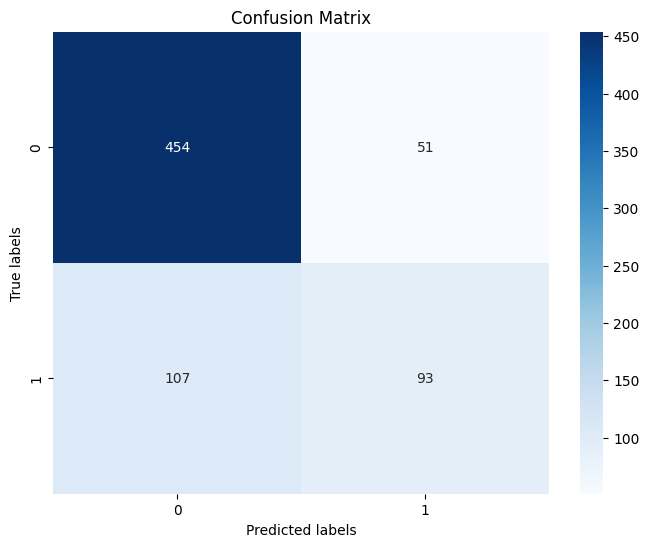

In [76]:
conf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show();

## Мы видим, что неправильно классифицированы 107 абонентов, когда наша модель предсказала, что оттока не будет, но отток случился и именно это число мы хотели бы минимизировать, так как здесь мы упускаем тех, кто уходит в отток. Кроме этого, есть ещё 51 людей, для которых модель предсказала, что они уйдут в отток, но на самом деле они не ушли в отток.

In [77]:
imp_feats = pd.DataFrame(data=dt.feature_importances_, index=X.columns, columns=['Важность'])

In [79]:
imp_feats = imp_feats.sort_values('Важность')

In [80]:
imp_feats = imp_feats[imp_feats['Важность'] > 0]
imp_feats

,Важность
gender_Male,0.001259
TotalCharges_90.1,0.001865
TotalCharges_72.1,0.001884
TotalCharges_3563.8,0.001917
TotalCharges_3467,0.001931
TotalCharges_289.3,0.001982
TotalCharges_245.2,0.001995
TotalCharges_7723.7,0.002038
TotalCharges_6585.35,0.002049
TotalCharges_3184.25,0.002124


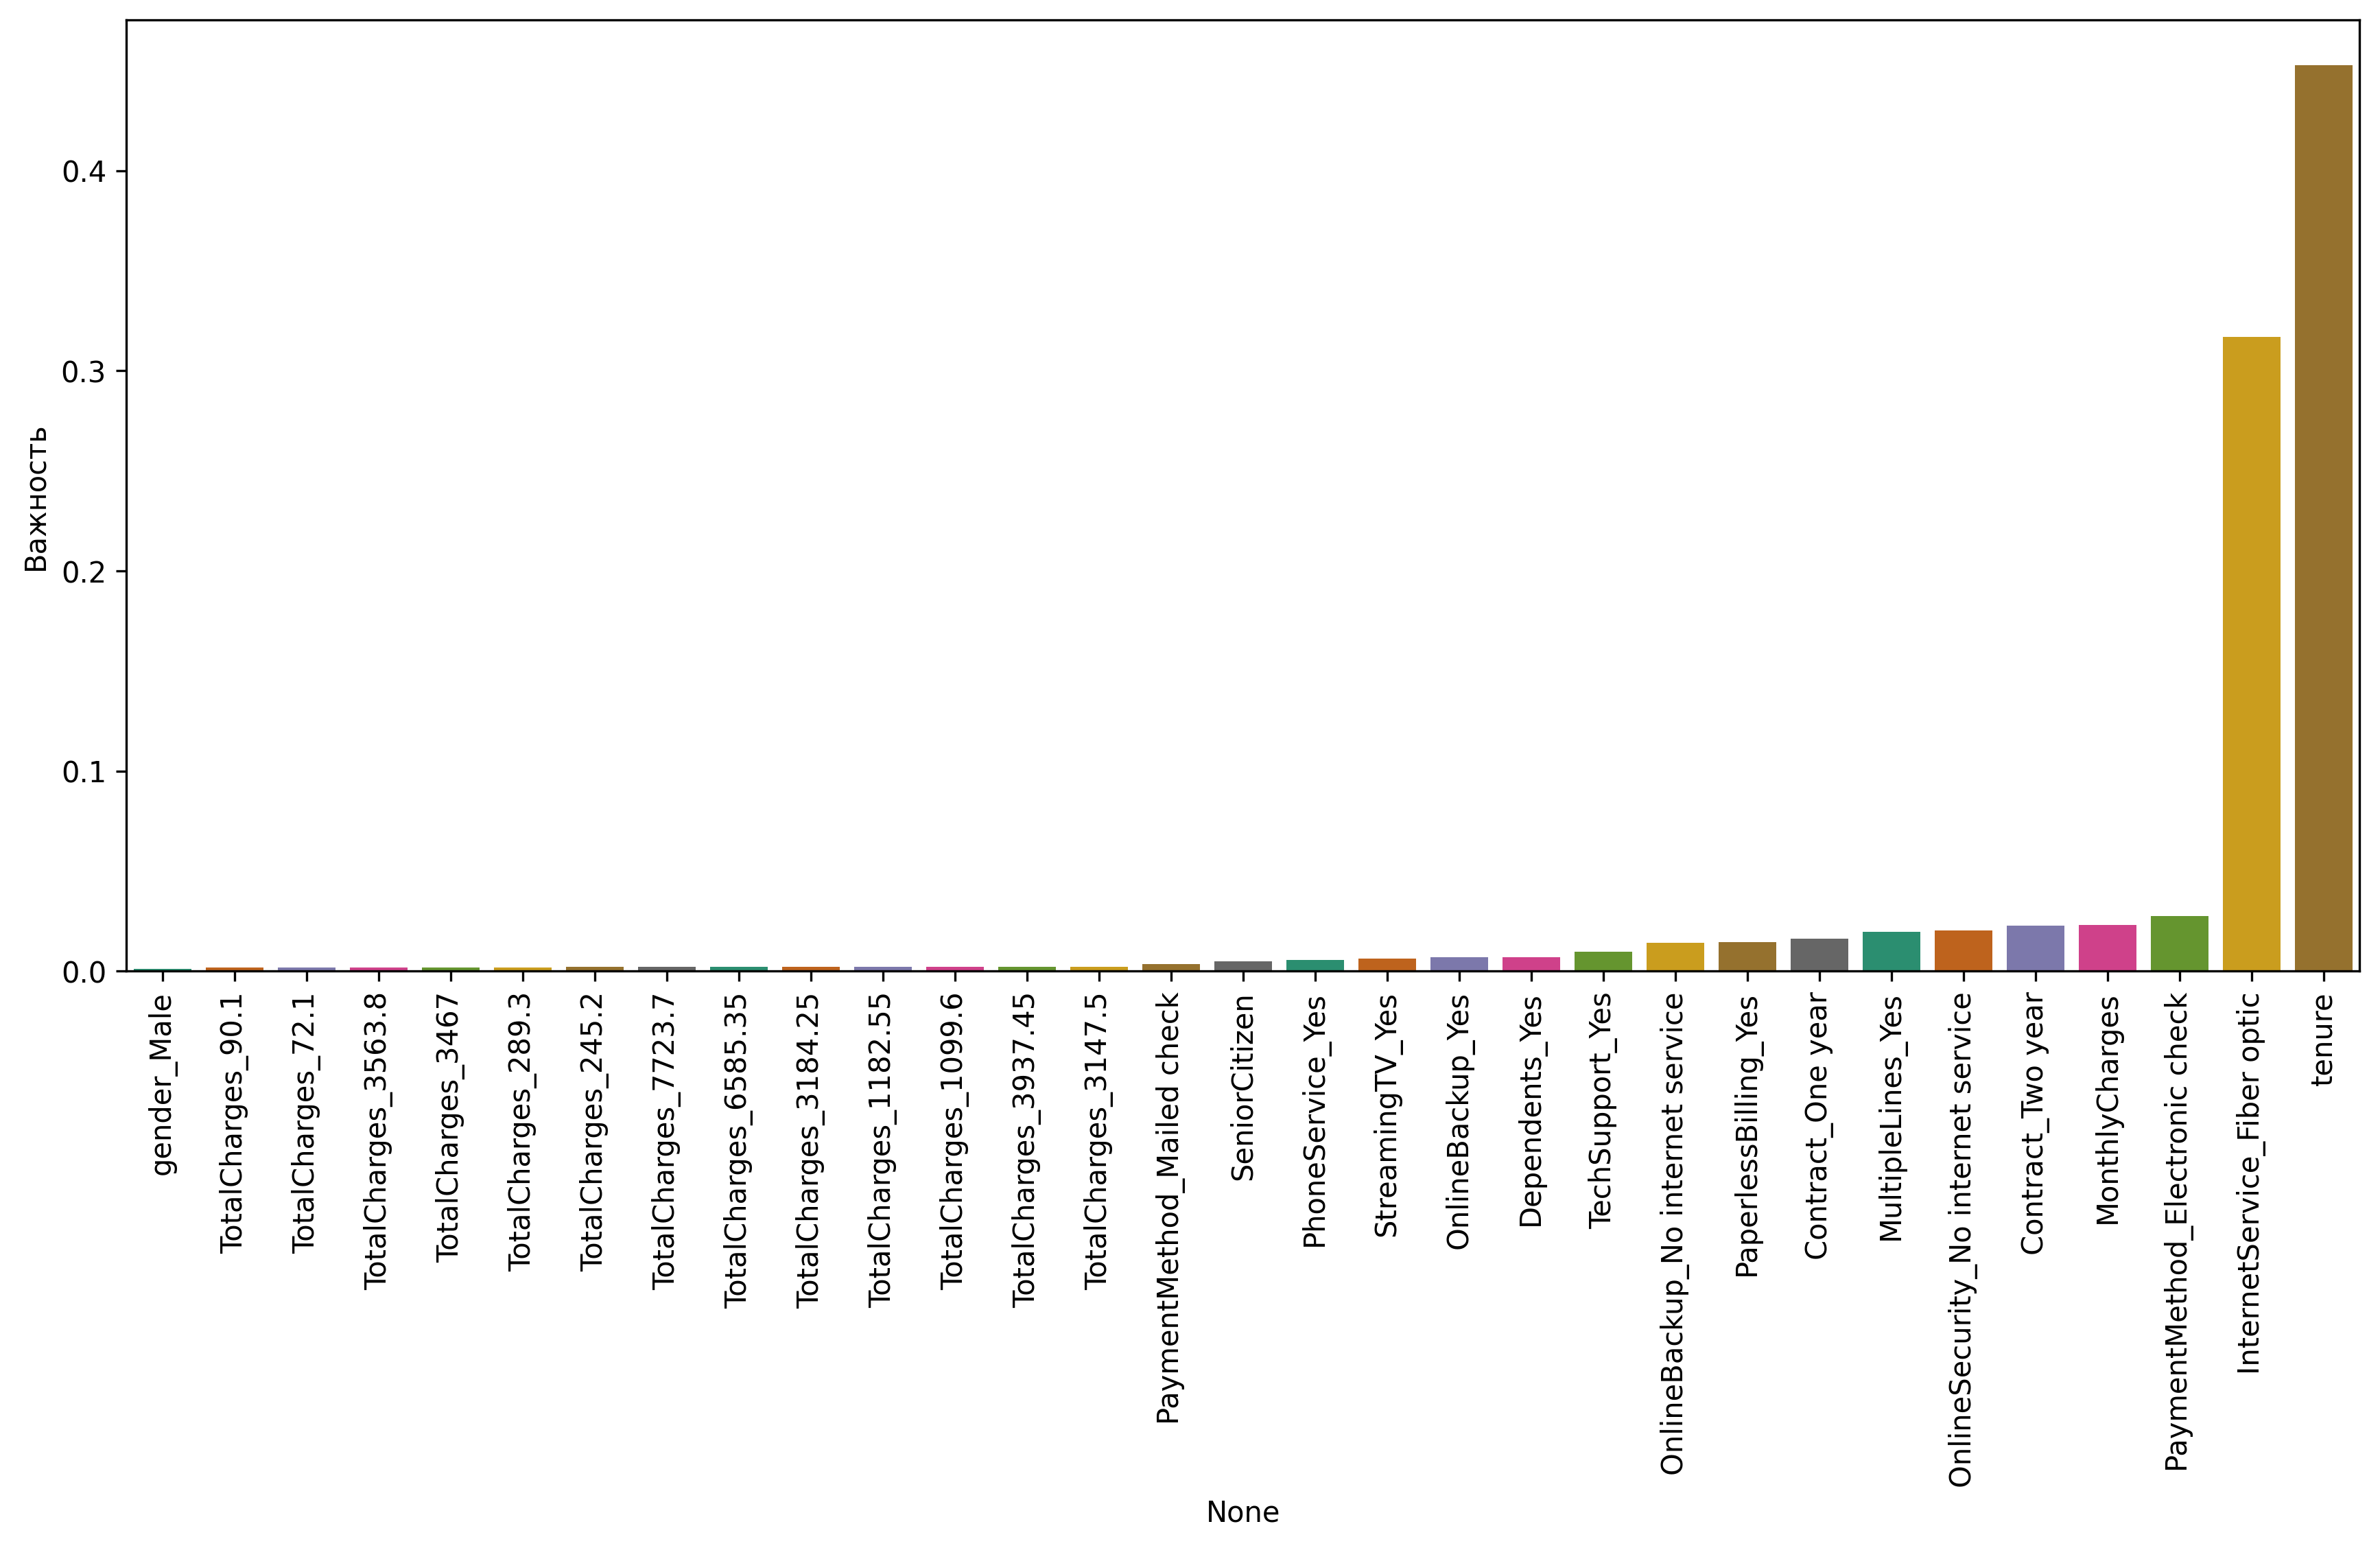

In [81]:
plt.figure(figsize=(14, 6), dpi=300)
sns.barplot(data=imp_feats, x=imp_feats.index, y='Важность', palette="Dark2")
plt.xticks(rotation=90);

## Ранее мы видели, что признак 'tenure' хорошо коррелирует с целевой переменной. Однако, есть ещё один интересный признак 'Internetservice_Fiber optic', который ранее не встречали нигде в исследовании. В этом случае нужно выяснять отдельно, почему клиенты, которые нуждаются в интернете по оптоволокну, могут уходить в отток. Возможно у кампании Telco выше цены, чем у конкурентов, именно по этой услуге.

## Сделаем визуализацию дерева решений

In [82]:
from sklearn.tree import plot_tree

[Text(0.5169902912621359, 0.9285714285714286, 'x[1] <= 16.5\ngini = 0.388\nsamples = 6338\nvalue = [4669.0, 1669.0]'),
 Text(0.2682038834951456, 0.7857142857142857, 'x[9] <= 0.5\ngini = 0.496\nsamples = 2283\nvalue = [1238, 1045]'),
 Text(0.39259708737864074, 0.8571428571428572, 'True  '),
 Text(0.1529126213592233, 0.6428571428571429, 'x[1] <= 3.5\ngini = 0.411\nsamples = 1310\nvalue = [932.0, 378.0]'),
 Text(0.07766990291262135, 0.5, 'x[11] <= 0.5\ngini = 0.485\nsamples = 565\nvalue = [331, 234]'),
 Text(0.038834951456310676, 0.35714285714285715, 'x[2] <= 60.2\ngini = 0.499\nsamples = 330\nvalue = [159, 171]'),
 Text(0.019417475728155338, 0.21428571428571427, 'x[25] <= 0.5\ngini = 0.495\nsamples = 296\nvalue = [133, 163]'),
 Text(0.009708737864077669, 0.07142857142857142, 'gini = 0.497\nsamples = 133\nvalue = [72, 61]'),
 Text(0.02912621359223301, 0.07142857142857142, 'gini = 0.468\nsamples = 163\nvalue = [61.0, 102.0]'),
 Text(0.05825242718446602, 0.21428571428571427, 'x[14] <= 0.5\n

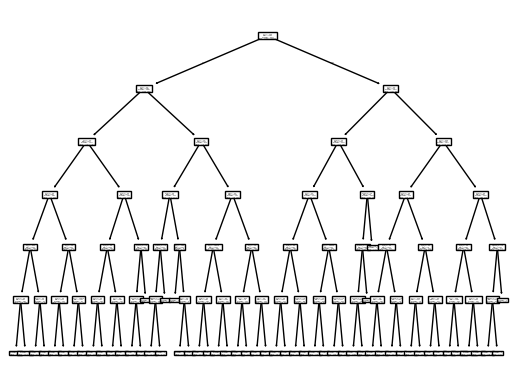

In [83]:
plot_tree(dt)

## Дерево решений получилось достаточно громоздким. Следует сказать, что для таких деревьев такая визуализация может оказаться избыточной для принятия бизнес-решений. Возможно имеет смысл посмотреть только на самые первые узлы разбиения данных, чтобы понять наиболее критичные признаки, по которым разбиваются данные.

## СЛУЧАЙНЫЙ ЛЕС (Random Forest)

## Построим модель Random Forest, оценим её работу и выполним её обучение

In [84]:
from sklearn.ensemble import RandomForestClassifier

In [100]:
rf = RandomForestClassifier(max_depth=6)

In [101]:
rf.fit(X_train, y_train)

RandomForestClassifier(max_depth=6)

In [102]:
preds = rf.predict(X_test)

In [103]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.72      1.00      0.83       505
         Yes       0.00      0.00      0.00       200

    accuracy                           0.72       705
   macro avg       0.36      0.50      0.42       705
weighted avg       0.51      0.72      0.60       705



 Почему так происходит?
Основная проблема — дисбаланс классов. В ваших данных:

Класс No имеет 505 объектов.

Класс Yes имеет 200 объектов.

Модель Random Forest, как и многие другие алгоритмы, склонна к предсказанию класса, который встречается чаще (в данном случае No), если не учитывать дисбаланс.

In [109]:
rf = RandomForestClassifier(max_depth=6, class_weight='balanced') # Используем параметр class_weight='balanced', чтобы модель учитывала дисбаланс классов.

In [105]:
rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=6)

In [106]:
preds = rf.predict(X_test)

In [107]:
print(classification_report(y_test, preds))

              precision    recall  f1-score   support

          No       0.92      0.67      0.77       505
         Yes       0.50      0.85      0.63       200

    accuracy                           0.72       705
   macro avg       0.71      0.76      0.70       705
weighted avg       0.80      0.72      0.73       705



Модель стала лучше справляться с классом Yes, что важно для задачи предсказания оттока (так как обычно класс Yes — это меньшинство, и его правильное предсказание критично).

Однако это произошло за счет снижения Recall для класса No. Это может быть приемлемо, если цель — минимизировать пропуск оттока (False Negatives для класса Yes).

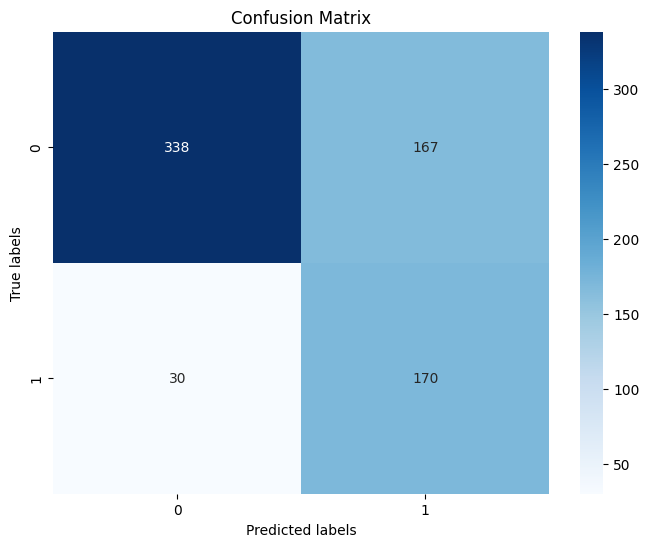

In [108]:
conf_matrix = confusion_matrix(y_test, preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show();

## Видно, что эта модель работает немного хуже чем  модель "Decision Tree"(важно счесть, какая метрика учитывается и сравнивается). Причина в том, что дерево решений получилось слишком глубоким, и из-за этого модель может получится переобученной(overfitting), т.е. хорошо работать на обученных данных и плохо работать на тестовых данных. Поэтому в определённых ситуациях полезно ограничивать глубину дерева(max_depth).

## РАСШИРЯЕМЫЕ ДЕРЕВЬЯ (Boosted Trees)

## Создадим модель AdaBoost и Gradient Boosting, оценим их работу и выполним обучение.

In [110]:
from sklearn.ensemble import  AdaBoostClassifier

In [122]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),  # Базовая модель (дерево с глубиной 1)
    n_estimators=118,  # Количество слабых моделей
    learning_rate=0.5  # Скорость обучения
)

In [123]:
ada_model.fit(X_train, y_train)

AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1),
                   learning_rate=0.5, n_estimators=118)

In [124]:
ada_preds = ada_model.predict(X_test)

In [125]:
print(classification_report(y_test, ada_preds))

              precision    recall  f1-score   support

          No       0.81      0.91      0.86       505
         Yes       0.67      0.46      0.54       200

    accuracy                           0.78       705
   macro avg       0.74      0.68      0.70       705
weighted avg       0.77      0.78      0.77       705



In [126]:
ada_model.feature_importances_

array([0.01497933, 0.39210076, 0.        , ..., 0.        , 0.        ,
       0.        ])

In [127]:
ada_model.feature_importances_.argmax()

1

In [128]:
X.columns[1]

'tenure'

## Получили, что в модели AdaBoost наиболее важное значение имеет признак 'TotalCharges'. И это справедливо, так как показывает сколько всего расходов понёс клиент в кампании Telco, и также данный признак достаточно хорошо коррелирует с целевой переменной 'Churn'.

## Оптимизируем модель

In [ ]:
from sklearn.metrics import accuracy_score

error_rates = []

for n in range(1, 120):
    best_ada_model = AdaBoostClassifier(n_estimators=n)
    best_ada_model.fit(X_train, y_train)
    best_ada_preds = best_ada_model.predict(X_test)

    err = 1 - accuracy_score(y_test, best_ada_preds)

    error_rates.append(err)

## При увеличении количества деревьев ошибка модели должна уменьшатся.

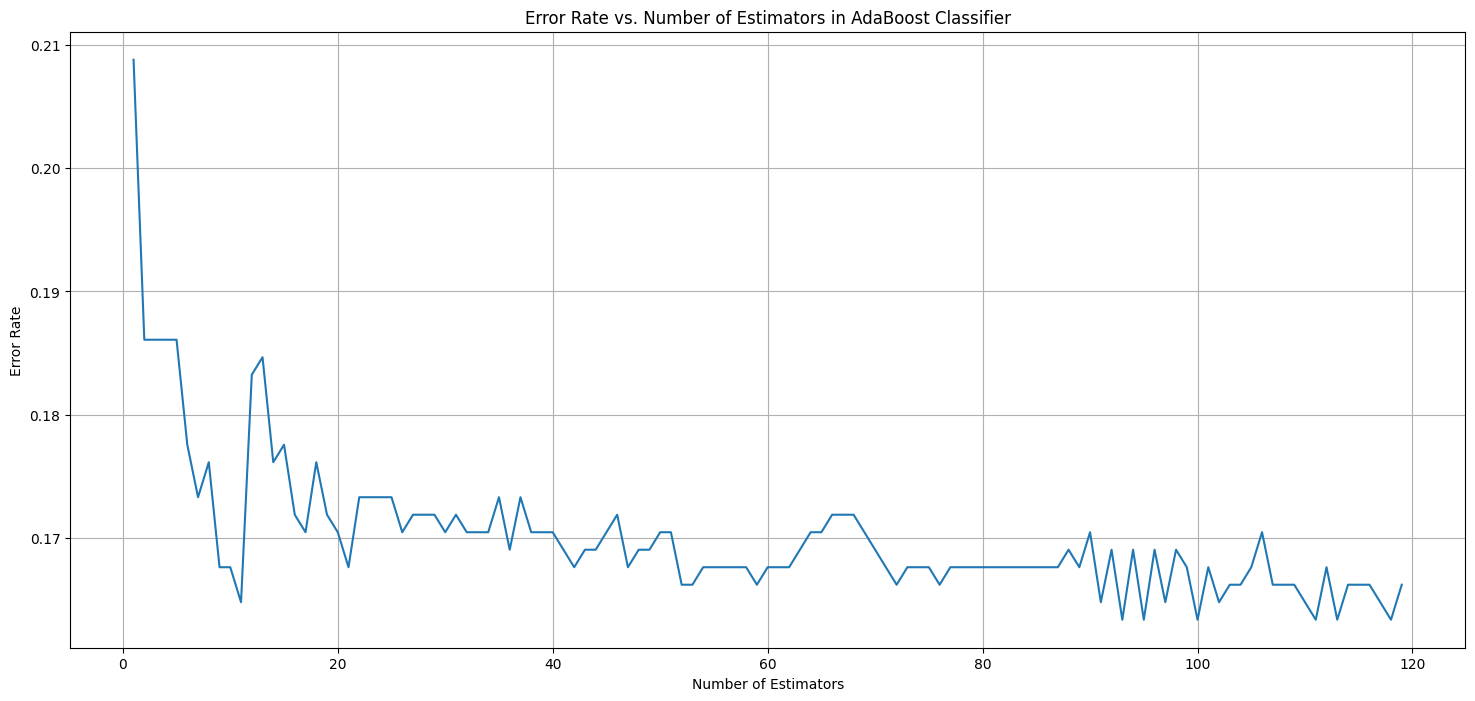

In [ ]:
plt.figure(figsize=(18, 8))
plt.plot(range(1, 120), error_rates)
plt.title('Error Rate vs. Number of Estimators in AdaBoost Classifier')
plt.xlabel('Number of Estimators')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show();

##  По графику оптимальное значение ошибки находится где-то в районе 118. Это значение мы и указали при обучении модели выше.

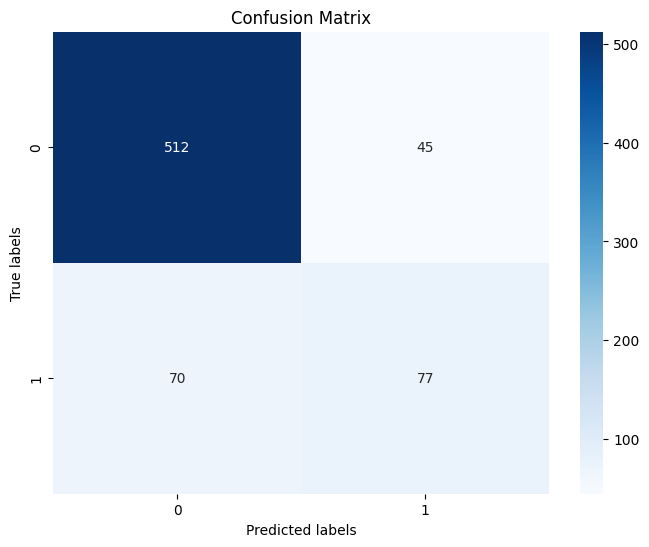

In [ ]:
conf_matrix = confusion_matrix(y_test, ada_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show();

## Мы уменьшили значение метрики recall. И это значение равно 70.

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV

In [ ]:
param_grid = {'n_estimators': [50, 60, 70, 80, 90, 100, 110, 120, 130],
              'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9],
              'max_depth': [3, 4, 5, 6, 7, 8, 9]}

In [ ]:
gb_model = GradientBoostingClassifier()

In [ ]:
grid = GridSearchCV(estimator=gb_model, param_grid=param_grid)

In [ ]:
grid.fit(X_train, y_train)

GridSearchCV(estimator=GradientBoostingClassifier(),
             param_grid={'learning_rate': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7,
                                           0.8, 0.9],
                         'max_depth': [3, 4, 5, 6, 7, 8, 9],
                         'n_estimators': [50, 60, 70, 80, 90, 100, 110, 120,
                                          130]})

In [ ]:
gb_preds = grid.predict(X_test)

In [ ]:
grid.best_estimator_

GradientBoostingClassifier(n_estimators=80)

In [ ]:
grid.best_params_

{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 80}

In [ ]:
print(classification_report(y_test, gb_preds))

              precision    recall  f1-score   support

          No       0.88      0.90      0.89       557
         Yes       0.59      0.51      0.55       147

    accuracy                           0.82       704
   macro avg       0.73      0.71      0.72       704
weighted avg       0.81      0.82      0.82       704



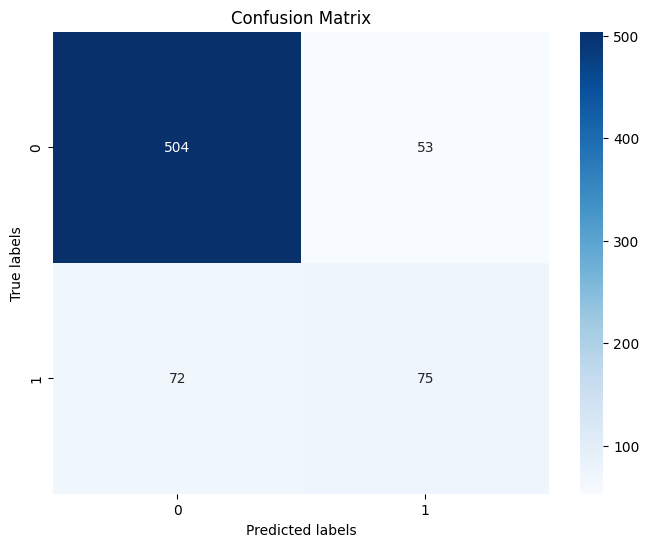

In [ ]:
conf_matrix = confusion_matrix(y_test, gb_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show();

## Если сделаем вывод, то можно сказать, что модель Adaboost с использованием гиперпараметров работает чуть хуже чем модель расширяемые деревья.


## Модель логистической регрессии

## Построим модель логистической регрессии

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegressionCV

In [ ]:
scaler = StandardScaler()

In [ ]:
scaled_X_train = scaler.fit_transform(X_train)

In [ ]:
scaleed_X_test = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegressionCV()

In [ ]:
log_model.fit(scaled_X_train, y_train)

LogisticRegressionCV()

## Посмотрим на оптимальные значения логистической регрессии

In [ ]:
log_model.Cs_

array([1.00000000e-04, 7.74263683e-04, 5.99484250e-03, 4.64158883e-02,
       3.59381366e-01, 2.78255940e+00, 2.15443469e+01, 1.66810054e+02,
       1.29154967e+03, 1.00000000e+04])

In [ ]:
log_model.C_#выбор наилучшего значения

array([0.04641589])

In [ ]:
log_model.get_params()

{'Cs': 10,
 'class_weight': None,
 'cv': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1.0,
 'l1_ratios': None,
 'max_iter': 100,
 'multi_class': 'auto',
 'n_jobs': None,
 'penalty': 'l2',
 'random_state': None,
 'refit': True,
 'scoring': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0}

## Посмотрим на коэффициенты модели

In [ ]:
log_model.coef_

array([[ 8.50978351e-02, -7.35111542e-01,  1.29221171e-01,
        -1.56351333e-02,  4.79987953e-04, -1.50747632e-02,
        -4.43580136e-02, -8.03040647e-02,  8.03040647e-02,
         1.30196342e-01,  3.91037246e-01, -4.17105411e-02,
        -4.17105411e-02, -1.79349219e-01, -4.17105411e-02,
        -6.87981541e-02, -4.17105411e-02, -4.86559668e-04,
        -4.17105411e-02, -1.56171995e-01, -4.17105411e-02,
         1.17666197e-01, -4.17105411e-02,  9.53287254e-02,
        -2.96495051e-01, -5.95550305e-01,  1.66288540e-01,
        -4.32903180e-02,  1.47591543e-01, -2.23400002e-02,
        -1.67639596e-01, -1.51422564e-01, -1.83869135e-02]])

In [ ]:
coefs = pd.Series(index=X.columns, data=log_model.coef_[0]).sort_values()
coefs

tenure                                  -0.735112
Contract_Two year                       -0.595550
Contract_One year                       -0.296495
OnlineSecurity_Yes                      -0.179349
Tenure Cohort_12-24 месяцев             -0.167640
TechSupport_Yes                         -0.156172
Tenure Cohort_24-48 месяцев             -0.151423
PhoneService_Yes                        -0.080304
OnlineBackup_Yes                        -0.068798
Dependents_Yes                          -0.044358
PaymentMethod_Credit card (automatic)   -0.043290
DeviceProtection_No internet service    -0.041711
OnlineBackup_No internet service        -0.041711
StreamingMovies_No internet service     -0.041711
InternetService_No                      -0.041711
StreamingTV_No internet service         -0.041711
OnlineSecurity_No internet service      -0.041711
TechSupport_No internet service         -0.041711
PaymentMethod_Mailed check              -0.022340
Tenure Cohort_Более 48 месяцев          -0.018387


In [ ]:
y_pred = log_model.predict(scaleed_X_test)

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

          No       0.87      0.91      0.89       557
         Yes       0.61      0.50      0.55       147

    accuracy                           0.83       704
   macro avg       0.74      0.71      0.72       704
weighted avg       0.82      0.83      0.82       704



## Построим график "ROC Curve"

In [ ]:
from sklearn.metrics import roc_curve, RocCurveDisplay

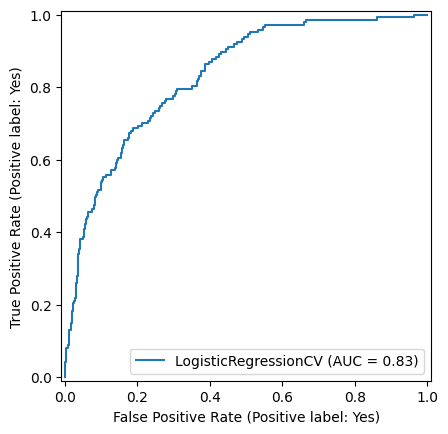

In [ ]:
RocCurveDisplay.from_estimator(log_model, scaleed_X_test, y_test);

## LogisticRegressionCV(AUC=0.83) в нашем случае означает, что была применена модель логистической регрессии с кросс-валидацией, и значение площади под кривой ROC (AUC) для данной модели составляет 0.83. AUC является метрикой, которая измеряет качество классификационной модели, где значение ближе к 1 указывает на более точную модель. Таким образом, значение AUC=0.83 указывает на хорошее качество модели логистической регрессии.

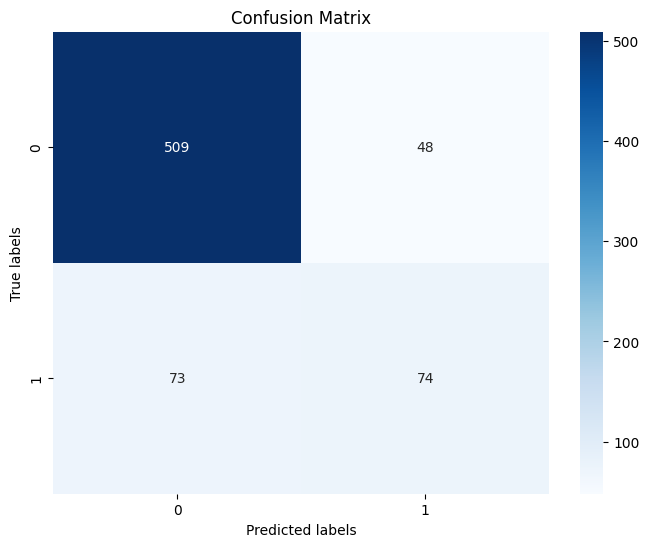

In [ ]:
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show();

## Видно что логистическая регрессия немного хуже отрабатывает, чем модель AdaBoost. Метрика recall равна 73. Ранее наилучшее значение мы получали 70.

## Метод опорных векторов(SVM)

In [ ]:
from sklearn.svm import SVC

In [ ]:
svc = SVC(class_weight='balanced')

In [ ]:
param_grid = {'C':[0.001, 0.01, 0.1, 0.5, 1]}

In [ ]:
grid = GridSearchCV(svc, param_grid)

In [ ]:
grid.fit(scaled_X_train, y_train)

GridSearchCV(estimator=SVC(class_weight='balanced'),
             param_grid={'C': [0.001, 0.01, 0.1, 0.5, 1]})

In [ ]:
grid.best_params_

{'C': 1}

In [ ]:
grid_preds = grid.predict(scaleed_X_test)

In [ ]:
confusion_matrix(y_test, grid_preds)

array([[410, 147],
       [ 37, 110]])

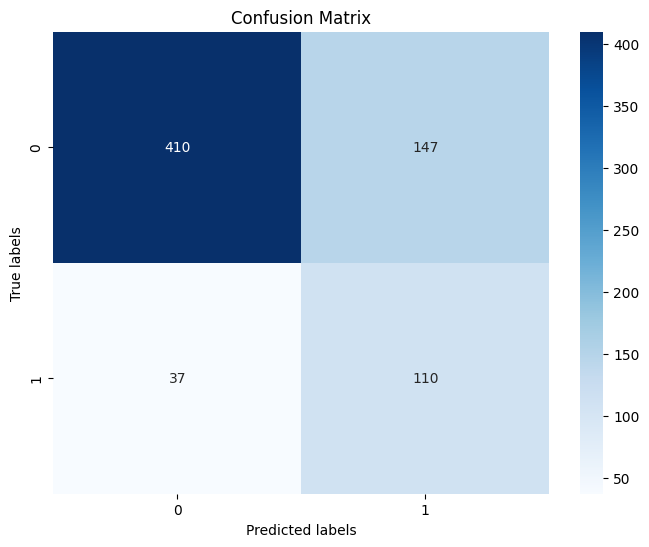

In [ ]:
conf_matrix = confusion_matrix(y_test, grid_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show();

In [ ]:
print(classification_report(y_test, grid_preds))

              precision    recall  f1-score   support

          No       0.92      0.74      0.82       557
         Yes       0.43      0.75      0.54       147

    accuracy                           0.74       704
   macro avg       0.67      0.74      0.68       704
weighted avg       0.82      0.74      0.76       704



## Мы получили наилучшее значение recall равной 37. Уменьшили ошибку предсказания для этой метрики почти в 2 раза, по сравнению с предыдущими моделями

## Метод К-ближайших соседей(KNN)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
knn = KNeighborsClassifier()

## Создадим пайплайн для данной модели

In [ ]:
from sklearn.pipeline import Pipeline

In [ ]:
operations = [('scaler', scaler), ('knn', knn)]

In [ ]:
pipe = Pipeline(operations)

In [ ]:
k_values = list(range(1, 30))

In [ ]:
param_grid = {'knn__n_neighbors': k_values}

In [ ]:
full_cv_classifier = GridSearchCV(pipe, param_grid, cv=5, scoring='accuracy')

In [ ]:
full_cv_classifier.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('knn', KNeighborsClassifier())]),
             param_grid={'knn__n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11,
                                              12, 13, 14, 15, 16, 17, 18, 19,
                                              20, 21, 22, 23, 24, 25, 26, 27,
                                              28, 29]},
             scoring='accuracy')

In [ ]:
full_cv_classifier.best_estimator_.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()),
  ('knn', KNeighborsClassifier(n_neighbors=28))],
 'verbose': False,
 'scaler': StandardScaler(),
 'knn': KNeighborsClassifier(n_neighbors=28),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'knn__algorithm': 'auto',
 'knn__leaf_size': 30,
 'knn__metric': 'minkowski',
 'knn__metric_params': None,
 'knn__n_jobs': None,
 'knn__n_neighbors': 28,
 'knn__p': 2,
 'knn__weights': 'uniform'}

In [ ]:
pd.DataFrame(full_cv_classifier.cv_results_).head()


,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_knn__n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.008166,0.001887,0.033013,0.008638,1,{'knn__n_neighbors': 1},0.729068,0.728278,0.703002,0.715415,0.713043,0.717761,0.009839,29
1,0.007286,0.000194,0.029410,0.000306,2,{'knn__n_neighbors': 2},0.756714,0.757504,0.747235,0.746245,0.762846,0.754109,0.006383,27
2,0.007051,0.000215,0.033983,0.006227,3,{'knn__n_neighbors': 3},0.761453,0.750395,0.729068,0.760474,0.760474,0.752373,0.012335,28
3,0.007751,0.000189,0.039827,0.001099,4,{'knn__n_neighbors': 4},0.782780,0.770142,0.748815,0.760474,0.769960,0.766435,0.011308,24
4,0.007426,0.000263,0.031939,0.001291,5,{'knn__n_neighbors': 5},0.771722,0.753555,0.754344,0.756522,0.762846,0.759798,0.006796,26


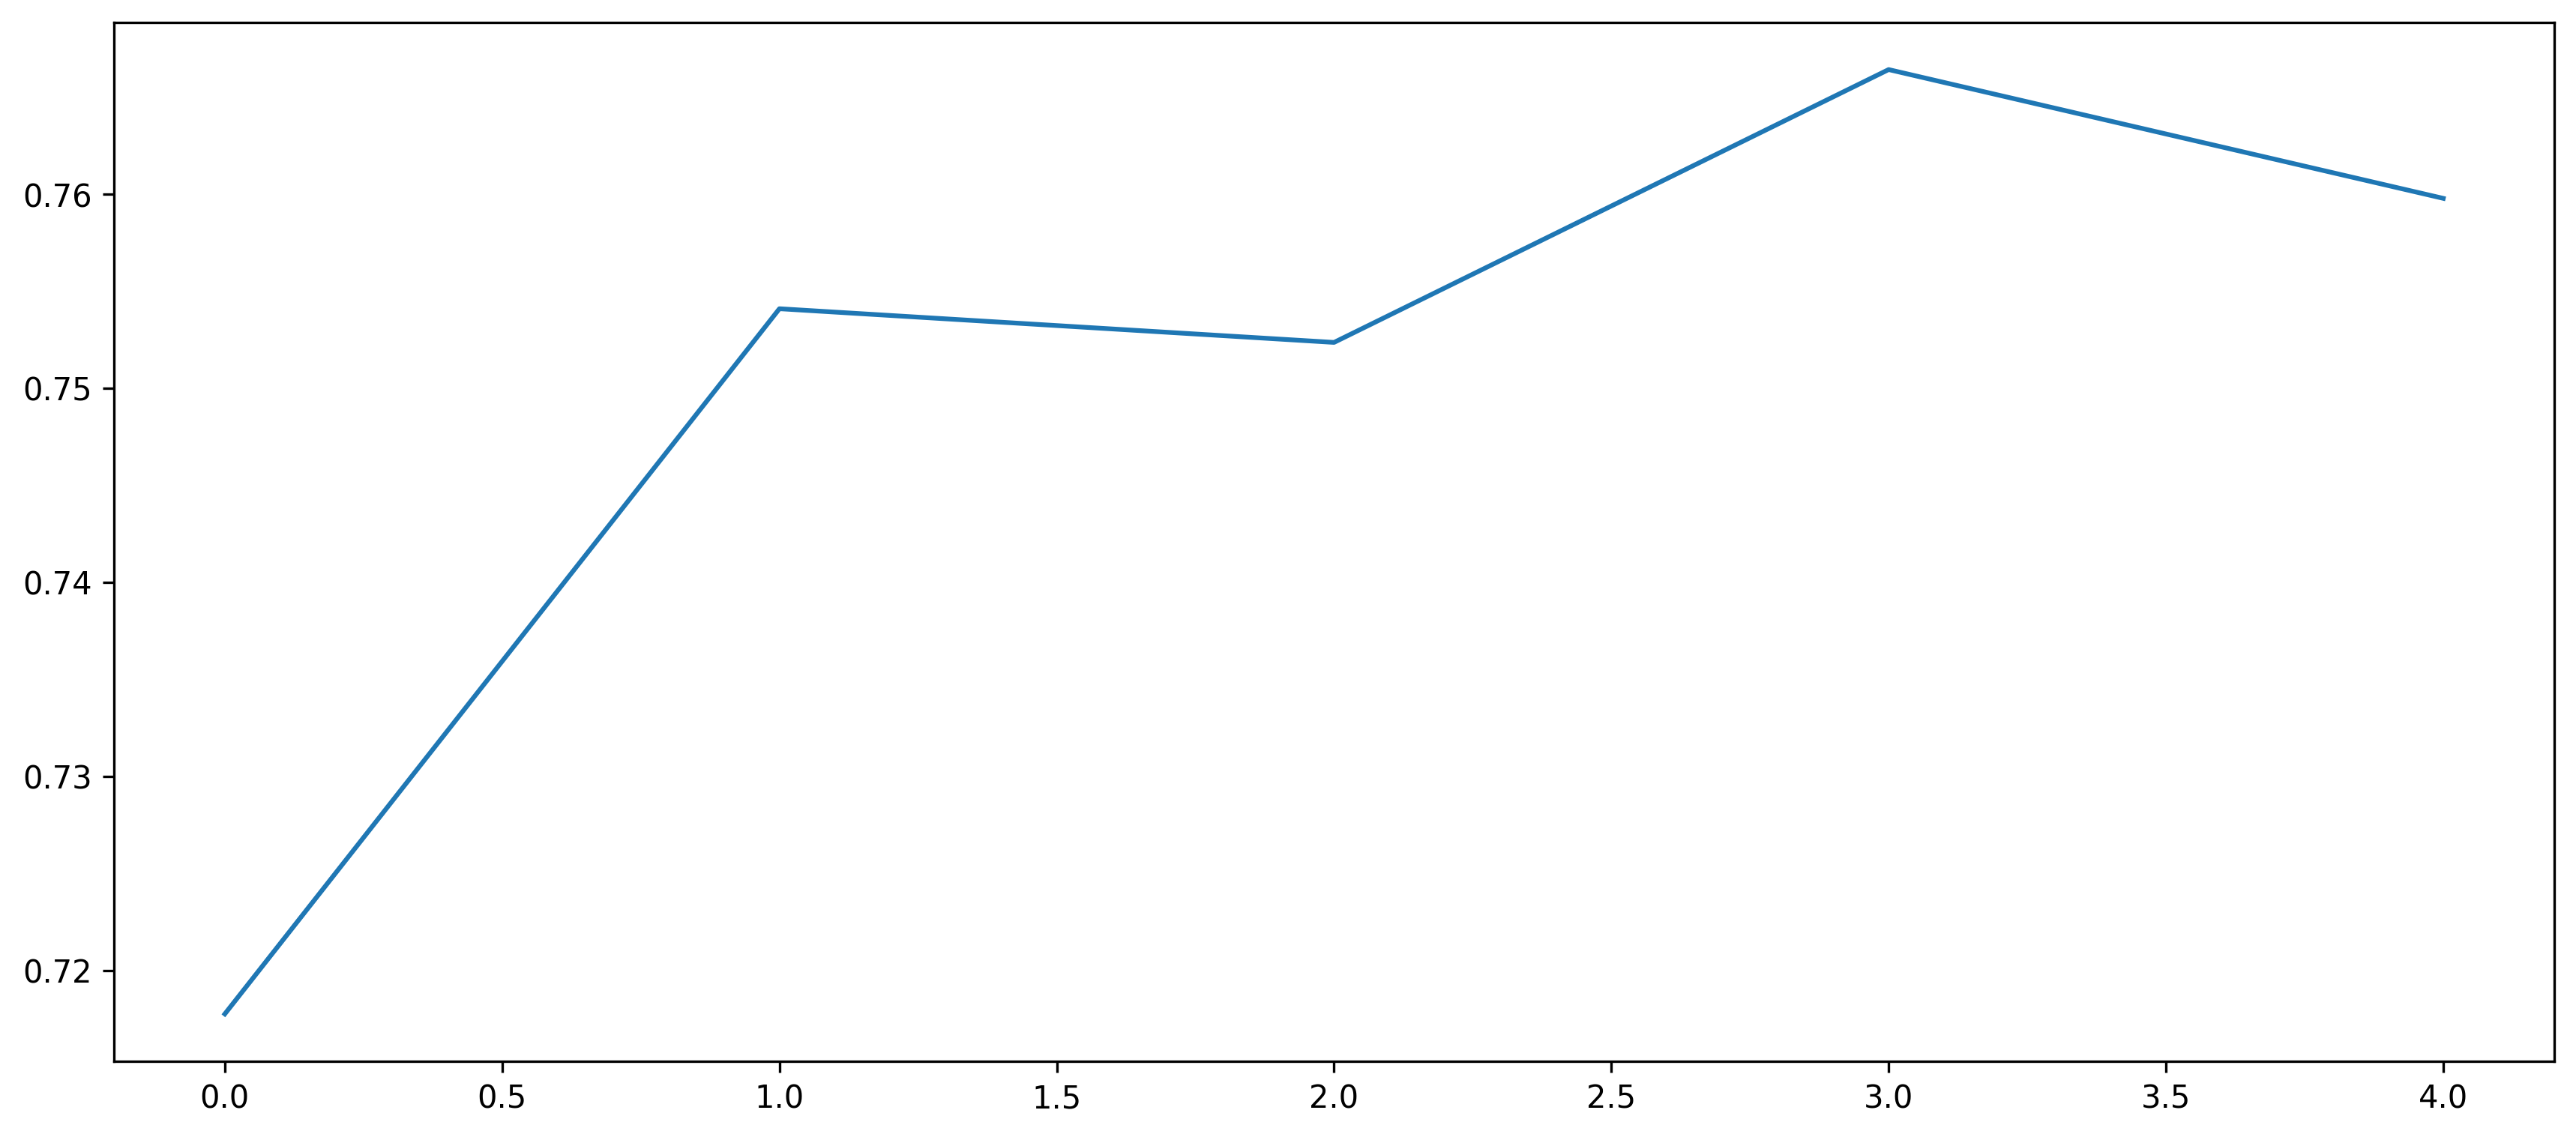

In [ ]:
plt.figure(figsize=(14, 6), dpi=300)
pd.DataFrame(full_cv_classifier.cv_results_).head()['mean_test_score'].plot();

In [ ]:
knn_pred = full_cv_classifier.predict(X_test)

In [ ]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

          No       0.87      0.89      0.88       557
         Yes       0.55      0.50      0.52       147

    accuracy                           0.81       704
   macro avg       0.71      0.70      0.70       704
weighted avg       0.80      0.81      0.81       704



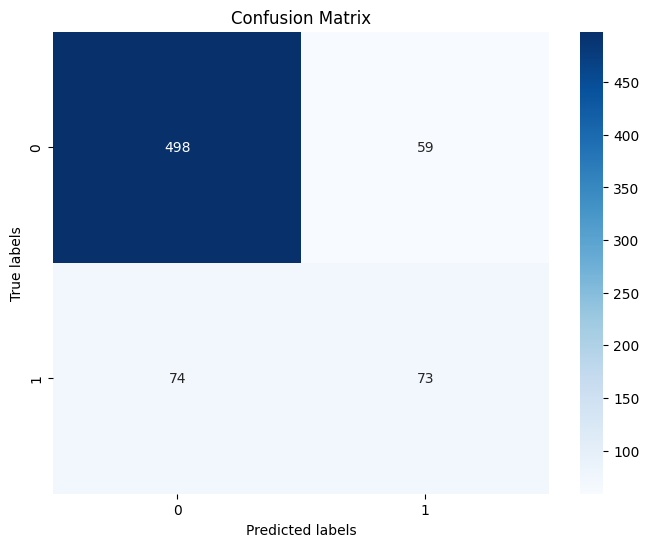

In [ ]:
conf_matrix = confusion_matrix(y_test, knn_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted labels')
plt.ylabel('True labels')
plt.title('Confusion Matrix')
plt.show();

## Значение recall получилось достаточно большим. Это хуже, чем у многих ранее рассмотренных моделей.

## Было выясненно, что наибольшее влияние на отток клиентов влияет показатель TotalCharges(общие расходы), и больше оттока наблюдается на краткосрочных контрактах. В связи с этим, кампании Telco рекомендуется пересмотреть условия краткосрочных контрактов(меньше года), чтобы удержать абонентов у себя. Исходя из этого, следует разработать некоторые мероприятия, которые удовлетворяли бы клиентов на контрактах меньше года.

## Наилучшей моделью для предсказания оказалась в нашем случае 'Метод опорных векторов(SVM)'.

## Модель для предсказания того, уйдут ли клиенты в оеток готова и можно её внедрять в продакшн. Можно это сделать разными способами. Рассмотрим один из них:

## Используем файл с расширением .pickle.

In [ ]:
import pickle

In [ ]:
# Выбор наилучшей модели
svc = SVC(class_weight='balanced')
param_grid = {'C': [0.001, 0.01, 0.1, 0.5, 1]}
grid = GridSearchCV(svc, param_grid)
grid.fit(scaled_X_train, y_train)
# Сохранение модели в файл
with open('model.pickle', 'wb') as file:
    pickle.dump(grid, file)

## Для загрузки модели из файла в будущем, можно использовать pickle.load():

In [ ]:
with open('model.pickle', 'rb') as file:
    loaded_model = pickle.load(file)
# Теперь можно использовать загруженную модель для предсказаний
grid_preds = loaded_model.predict(scaleed_X_test)

##  Таким образом, можно сохранять обученную модель в файл и затем загружать её для использования в продакшене.